# Biologically-Informed Kinetic Growth Modelling

Reconstructs missing/right-censored `post_threshold_(day)` and `post_threshold_count`
values in `combined_shelf_life.csv` using kinetic modelling instead of statistical
imputation, before those values feed the GAN retraining in `data_filling.ipynb`.

**Two parallel tracks**, since the dataset mixes two physically different phenomena:

1. **Microbial growth** (476/964 rows, `unit == "log cfu/g"`) - sigmoidal bacterial
   growth, modelled with **Baranyi** (Baranyi & Roberts, 1994) and **modified Gompertz**
   (Zwietering et al., 1990), following the ML-assisted methodology of:
   - Tarlak, F.; Simsek, B.B.; Sahin, M.; Perez-Rodriguez, F. *Next-Generation Predictive
     Microbiology: A Software Platform Combining Two-Step, One-Step and Machine Learning
     Modelling.* Foods 2025, 14, 3158.
   - Tarlak, F.; Yucel, O. *Assessment of robustness of machine learning-assisted
     modelling approach to describe growth kinetics of microorganisms using Monte Carlo
     simulation.* J. Food Nutr. Res. 2024, 63(3), 273-282.
2. **Chemical spoilage kinetics** (488/964 rows - TVB-N, TBARS/MDA, peroxide value, etc.)
   - monotonic accumulation from lipid oxidation/protein degradation, not sigmoidal
   growth. Modelled with **zero-order** (linear) and **first-order**
   (exponential-approach-to-ceiling) reaction kinetics. Not from the two papers above
   (microbial-only) - this notebook's own extension, using an analogous
   fit/censor/reconstruct pipeline for physically-appropriate treatment of all 964 rows.

## Key data-reality difference from the two papers

The 2025 paper's datasets (Gospavic et al., Lytou et al., Possas et al.) provide dense
multi-point time series per condition (33-44 points/curve). This dataset instead gives
each row an **independent 3-point trajectory**: `(day 0, initial_count)` ->
`(pre_threshold_day, pre_threshold_count)` -> `(post_threshold_day, post_threshold_count)`.
`experiment_id`/`ingredient_id` are batch/study identifiers, not a shared time axis. So
y0 is fixed from day-0, ymax is bounded empirically, leaving 2 free parameters
(rate+lag or rate+ceiling) per row.

## Table of Contents

1. [Setup and Imports](#1-setup-and-imports)
2. [Load Data & Split Into Tracks](#2-load-data--split-into-tracks)
3. [Model Equations (Baranyi, Gompertz, Zero-Order, First-Order)](#3-model-equations)
4. [Row Classification (Censoring Types)](#4-row-classification)
5. [Curve-Fitting Routine](#5-curve-fitting-routine)
6. [Batch Fitting — Microbial & Chemical Tracks](#6-batch-fitting)
7. [Fit Diagnostics & Visualization](#7-fit-diagnostics--visualization)
8. [Feature Engineering for ML Regressors](#8-feature-engineering)
9. [GPR vs RFR Comparison](#9-gpr-vs-rfr-comparison)
10. [Reconstruction of Censored Rows](#10-reconstruction-of-censored-rows)
11. [Held-Out Validation (the credibility check)](#11-held-out-validation)
12. [Comparison & Visualization of Imputed vs Original](#12-comparison--visualization)
13. Merge Back Into Full Dataset *(planned — not yet implemented)*

## 1. Setup and Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import sys
import json
import math
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import least_squares, brentq

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT       = Path("..").resolve()
DATA_DIR   = ROOT / "data"
PROC_DIR   = DATA_DIR / "processed"
FIG_DIR    = PROC_DIR / "figures"
MODELS_DIR = PROC_DIR / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(ROOT / "notebooks"))
from _shared_formulas import compute_inhibition_features

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

REFIT = False  # if False and cache CSVs exist, load cached fits instead of recomputing

print(f"ROOT: {ROOT}")
print(f"DATA_DIR: {DATA_DIR}")

ROOT: C:\Users\safae\projects\ML
DATA_DIR: C:\Users\safae\projects\ML\data


## 2. Load Data & Split Into Tracks

`unit == "log cfu/g"` cleanly separates the microbial-count track (sigmoidal growth)
from the chemical-indicator track (TVB-N, TBARS/MDA, peroxide value, etc. — monotonic
accumulation). The row counts are asserted so any upstream change to the source CSV
fails loudly here rather than silently changing which model family gets applied.

In [ ]:
SRC_CSV = PROC_DIR / "combined_shelf_life.csv"
df_raw = pd.read_csv(SRC_CSV)
print(f"Loaded {SRC_CSV.name}: {df_raw.shape[0]} rows x {df_raw.shape[1]} cols")

assert df_raw.shape[0] == 964, f"expected 964 rows, got {df_raw.shape[0]}"

df_micro = df_raw[df_raw["unit"] == "log cfu/g"].copy()
df_chem  = df_raw[df_raw["unit"] != "log cfu/g"].copy()

assert len(df_micro) == 476, f"expected 476 microbial rows, got {len(df_micro)}"
assert len(df_chem) == 488, f"expected 488 chemical rows, got {len(df_chem)}"
assert len(df_micro) + len(df_chem) == len(df_raw)

print(f"Microbial track (log cfu/g): {len(df_micro)} rows")
print(f"Chemical track (other units): {len(df_chem)} rows")
print()
print("Chemical track unit breakdown:")
print(df_chem["unit"].value_counts())

Loaded combined_shelf_life.csv: 964 rows x 36 cols
Microbial track (log cfu/g): 476 rows
Chemical track (other units): 488 rows

Chemical track unit breakdown:
unit
mg n/100g         140
mg mda/kg          96
mg mda per kg      62
meq o2/kg          56
meq/kg             29
mg/100g            26
cfu/plate          21
ppm                19
meq o2/kg fat      10
fungal count/g      9
mda/kg              8
%                   3
Name: count, dtype: int64


## 3. Model Equations

Four pure functions, each `f(t, ...) -> np.ndarray`. `y0` is always fixed (Decision 4);
`ymax`/`yceil` is bounded, not fixed (Decision 5), so both remain explicit fit
parameters alongside `mu_max`/`k` and `lag`.

- **Modified Gompertz** (Zwietering et al., 1990 reparameterization) — the numerically
  simpler default/primary attempt.
- **Baranyi** (Baranyi & Roberts, 1994) — log-domain adjustment-function form, with
  exponent clipping to avoid overflow for large `mu_max * t` products.
- **Zero-order** chemical kinetics — linear accumulation.
- **First-order** chemical kinetics — exponential approach to a ceiling.

In [ ]:
_EXP_CLIP = 700.0  # np.exp overflows above ~709 for float64


def gompertz_model(t, y0, ymax, mu_max, lag):
    t = np.asarray(t, dtype=float)
    e = np.e
    exponent = (mu_max * e / max(ymax - y0, 1e-9)) * (lag - t) + 1.0
    exponent = np.clip(exponent, -_EXP_CLIP, _EXP_CLIP)
    with np.errstate(over="ignore"):
        return y0 + (ymax - y0) * np.exp(-np.exp(exponent))


def _adjustment_function(t, mu_max, lag):
    """A(t) = t + (1/mu_max)*ln(exp(-mu_max*t)+exp(-mu_max*lag)-exp(-mu_max*(t+lag))).
    Stabilized by factoring out the max exponent so no term overflows/underflows."""
    t = np.asarray(t, dtype=float)
    mu_max = max(mu_max, 1e-9)
    a = -mu_max * t
    b = -mu_max * lag
    c = -mu_max * (t + lag)
    m = np.clip(np.maximum(a, b), -_EXP_CLIP, _EXP_CLIP)  # c <= min(a,b) always
    with np.errstate(over="ignore", under="ignore"):
        inner = np.exp(a - m) + np.exp(b - m) - np.exp(c - m)
    inner = np.clip(inner, 1e-300, None)
    with np.errstate(over="ignore"):
        return t + (1.0 / mu_max) * (m + np.log(inner))


def baranyi_model(t, y0, ymax, mu_max, lag):
    t = np.asarray(t, dtype=float)
    mu_max_safe = max(mu_max, 1e-9)
    A = _adjustment_function(t, mu_max_safe, lag)
    mu_A = np.clip(mu_max_safe * A, -_EXP_CLIP, _EXP_CLIP)
    dy = max(ymax - y0, 1e-9)
    with np.errstate(over="ignore"):
        exp_muA = np.exp(mu_A)
        ratio = (exp_muA - 1.0) / np.exp(np.clip(dy, -_EXP_CLIP, _EXP_CLIP))
    ratio = np.clip(ratio, -1.0 + 1e-12, None)
    return y0 + mu_max_safe * A - np.log1p(ratio)


def zero_order_model(t, y0, k):
    return y0 + k * np.asarray(t, dtype=float)


def first_order_model(t, y0, yceil, k):
    t = np.asarray(t, dtype=float)
    k_safe = max(k, 1e-9)
    return yceil - (yceil - y0) * np.exp(-k_safe * t)


print("Model functions defined: gompertz_model, baranyi_model, zero_order_model, first_order_model")


Model functions defined: gompertz_model, baranyi_model, zero_order_model, first_order_model


In [ ]:
_t_fine = np.linspace(0, 60, 400)
_y0_test, _ymax_test, _mu_test, _lag_test = 2.0, 9.0, 0.3, 5.0

# Baranyi is exact at t=0 (A(0)=0 => y(0)=y0). Zwietering Gompertz is only an
# approximation with f(0) ~ y0 (deviation shrinks as mu_max*lag grows) - expected.
_f0_tol = {"gompertz": 0.5, "baranyi": 1e-3}
_ymax_tol = {"gompertz": 0.05, "baranyi": 1e-2}

for name, fn, kwargs in [
    ("gompertz", gompertz_model, dict(y0=_y0_test, ymax=_ymax_test, mu_max=_mu_test, lag=_lag_test)),
    ("baranyi",  baranyi_model,  dict(y0=_y0_test, ymax=_ymax_test, mu_max=_mu_test, lag=_lag_test)),
]:
    y_fine = fn(_t_fine, **kwargs)
    f0 = fn(np.array([0.0]), **kwargs)[0]
    assert abs(f0 - _y0_test) < _f0_tol[name], f"{name}: f(0)={f0} too far from y0={_y0_test}"
    assert np.all(np.diff(y_fine) >= -1e-8), f"{name}: not monotonic non-decreasing"
    assert abs(y_fine[-1] - _ymax_test) < _ymax_tol[name], f"{name}: does not approach ymax as t->inf"
    print(f"{name}: f(0)={f0:.4f} (y0={_y0_test}), f(60)={y_fine[-1]:.4f} (ymax={_ymax_test}), monotonic OK")

_k_test, _yceil_test = 0.15, 40.0
y_zero = zero_order_model(_t_fine, y0=_y0_test, k=_k_test)
assert abs(y_zero[0] - _y0_test) < 1e-9
assert np.allclose(np.diff(y_zero), _k_test * (_t_fine[1] - _t_fine[0]))
print(f"zero_order: f(0)={y_zero[0]:.4f} (y0={_y0_test}), linear slope confirmed, no asymptote assertion (by design)")

y_first = first_order_model(_t_fine, y0=_y0_test, yceil=_yceil_test, k=_k_test)
assert abs(y_first[0] - _y0_test) < 1e-3
assert np.all(np.diff(y_first) >= -1e-8)
assert abs(y_first[-1] - _yceil_test) < 1e-1
print(f"first_order: f(0)={y_first[0]:.4f} (y0={_y0_test}), f(60)={y_first[-1]:.4f} (yceil={_yceil_test}), monotonic OK")

print("All model sanity checks passed.")

gompertz: f(0)=2.0539 (y0=2.0), f(60)=8.9687 (ymax=9.0), monotonic OK
baranyi: f(0)=2.0000 (y0=2.0), f(60)=8.9999 (ymax=9.0), monotonic OK
zero_order: f(0)=2.0000 (y0=2.0), linear slope confirmed, no asymptote assertion (by design)
first_order: f(0)=2.0000 (y0=2.0), f(60)=39.9953 (yceil=40.0), monotonic OK
All model sanity checks passed.


## 4. Row Classification

Each row's 3 potential (t, count) pairs - `(0, y0)`, `(pre_day, pre_count)`,
`(post_day, post_count)` - determine usable-point count and fitting path. Column names
are shared across both tracks; only physical meaning (log CFU/g vs. chemical units) differs.

when `post_threshold_(day)` is present but `post_threshold_count` is
missing, substitute `upper_level_threshold` at that day and treat as fully observed
(`"day_known_approx_crossing"`), not a penalty-constrained censored fit.

In [ ]:
def classify_row(row: pd.Series) -> dict:
    has_y0 = pd.notna(row["initial_count_(day_0)"])
    has_pre_day = pd.notna(row["pre_threshold_(day)"])
    has_pre_cnt = pd.notna(row["pre_threshold_count"])
    has_post_day = pd.notna(row["post_threshold_(day)"])
    has_post_cnt = pd.notna(row["post_threshold_count"])
    has_upper = pd.notna(row["upper_level_threshold_(log_cfu/g)"])

    pre_usable = has_pre_day and has_pre_cnt
    post_usable_observed = has_post_day and has_post_cnt
    post_usable_approx = has_post_day and (not has_post_cnt) and has_upper

    if not has_y0:
        n_usable_points = int(has_y0) + int(pre_usable) + int(post_usable_observed or post_usable_approx)
        return dict(n_usable_points=n_usable_points, is_censored=True,
                    censoring_type="missing_y0", fit_feasible=False)

    n_usable_points = 1 + int(pre_usable) + int(post_usable_observed or post_usable_approx)

    if post_usable_observed:
        return dict(n_usable_points=n_usable_points, is_censored=False,
                    censoring_type="observed", fit_feasible=True)
    if post_usable_approx:
        return dict(n_usable_points=n_usable_points, is_censored=False,
                    censoring_type="day_known_approx_crossing", fit_feasible=True)
    if pre_usable:
        return dict(n_usable_points=n_usable_points, is_censored=True,
                    censoring_type="fully_censored", fit_feasible=True)
    return dict(n_usable_points=n_usable_points, is_censored=True,
                censoring_type="underdetermined_single_point", fit_feasible=False)


def classify_track(df: pd.DataFrame) -> pd.DataFrame:
    records = [classify_row(row) for _, row in df.iterrows()]
    return pd.concat([df, pd.DataFrame(records, index=df.index)], axis=1)


print("classify_row / classify_track defined")


classify_row / classify_track defined


In [ ]:
MICRO_CLASSIFIED_CSV = PROC_DIR / "microbial_rows_classified.csv"
CHEM_CLASSIFIED_CSV = PROC_DIR / "chemical_rows_classified.csv"

df_micro_cls = classify_track(df_micro)
df_chem_cls = classify_track(df_chem)

df_micro_cls.to_csv(MICRO_CLASSIFIED_CSV, index=False)
df_chem_cls.to_csv(CHEM_CLASSIFIED_CSV, index=False)

print("=== Microbial track censoring_type counts ===")
print(df_micro_cls["censoring_type"].value_counts())
print(f"\nfit_feasible: {df_micro_cls['fit_feasible'].sum()} / {len(df_micro_cls)}")

print("\n=== Chemical track censoring_type counts ===")
print(df_chem_cls["censoring_type"].value_counts())
print(f"\nfit_feasible: {df_chem_cls['fit_feasible'].sum()} / {len(df_chem_cls)}")

=== Microbial track censoring_type counts ===
censoring_type
observed                        282
fully_censored                  158
day_known_approx_crossing        20
missing_y0                       12
underdetermined_single_point      4
Name: count, dtype: int64

fit_feasible: 460 / 476

=== Chemical track censoring_type counts ===
censoring_type
fully_censored               226
observed                     218
missing_y0                    38
day_known_approx_crossing      6
Name: count, dtype: int64

fit_feasible: 450 / 488


## 5. Curve-Fitting Routine

`fit_growth_curve_row` fits one row's (t,y) points against a 2-free-parameter model
(`rate` + `lag_or_ceiling`; y0 fixed, ymax bounded) via `scipy.optimize.least_squares`.
`ci_feasible` is only True when `n_points_used >= 3` - 2-point fits are exactly
determined, so RMSE/R2 look artificially perfect and must never be read as fit quality.

In [ ]:
@dataclass
class FitResult:
    rate: float
    lag_or_ceiling: float
    ymax: float
    rmse: float
    r2: float
    converged: bool
    n_points_used: int
    ci_feasible: bool
    param_cis: Optional[tuple] = None
    used_penalty: bool = False


def _param_cis_from_jacobian(result, residual_dof, alpha=0.05):
    from scipy import stats
    try:
        J = result.jac
        dof = max(residual_dof, 1)
        sigma2 = np.sum(result.fun**2) / dof
        cov = sigma2 * np.linalg.inv(J.T @ J)
        se = np.sqrt(np.clip(np.diag(cov), 0, None))
        tval = stats.t.ppf(1 - alpha / 2, dof)
        return tuple((p - tval * s, p + tval * s) for p, s in zip(result.x, se))
    except np.linalg.LinAlgError:
        return None


def fit_growth_curve_row(
    t_obs, y_obs, y0, ymax_bounds, model_fn,
    t_censor=None, upper_threshold=None, penalty_weight=50.0,
    rate_bounds=(1e-6, 10.0), lag_or_ceiling_bounds=None, is_ceiling_param=False,
):
    # t_censor (Decision 3): hinge penalty if predicted(t_censor) > upper_threshold.
    # Rarely triggers here since Decision 2 folds day-known rows into "observed".
    t_obs = np.asarray(t_obs, dtype=float)
    y_obs = np.asarray(y_obs, dtype=float)
    n_points = len(t_obs)
    ymax_lo, ymax_hi = ymax_bounds
    ymax_init = min(max(y_obs.max() + 0.1, ymax_lo), ymax_hi)
    if lag_or_ceiling_bounds is None:
        lag_or_ceiling_bounds = (0.0, max(t_obs.max() * 3, 10.0)) if not is_ceiling_param else (y0, ymax_hi * 2)
    rate_init = 0.2 if not is_ceiling_param else 0.1
    loc_init = (t_obs.max() / 2 if not is_ceiling_param else (ymax_init + y0) / 2)
    loc_init = min(max(loc_init, lag_or_ceiling_bounds[0] + 1e-6), lag_or_ceiling_bounds[1] - 1e-6)
    x0 = np.array([rate_init, loc_init, ymax_init])
    lb = np.array([rate_bounds[0], lag_or_ceiling_bounds[0], ymax_lo])
    ub = np.array([rate_bounds[1], lag_or_ceiling_bounds[1], ymax_hi])
    x0 = np.clip(x0, lb + 1e-9, ub - 1e-9)
    used_penalty = False

    def residuals(params):
        rate, loc, ymax = params
        pred = model_fn(t_obs, y0, ymax, rate, loc) if not is_ceiling_param else model_fn(t_obs, y0, loc, rate)
        res = pred - y_obs
        if t_censor is not None and upper_threshold is not None:
            pred_c = (model_fn(np.array([t_censor]), y0, ymax, rate, loc)
                      if not is_ceiling_param else model_fn(np.array([t_censor]), y0, loc, rate))[0]
            hinge = max(pred_c - upper_threshold, 0.0)
            if hinge > 0:
                nonlocal used_penalty
                used_penalty = True
            res = np.append(res, penalty_weight * hinge)
        return res

    try:
        result = least_squares(residuals, x0, bounds=(lb, ub), method="trf")
        converged = result.success
    except Exception:
        return FitResult(np.nan, np.nan, np.nan, np.nan, np.nan, False, n_points, False, None, False)

    rate_hat, loc_hat, ymax_hat = result.x
    y_pred = (model_fn(t_obs, y0, ymax_hat, rate_hat, loc_hat) if not is_ceiling_param
              else model_fn(t_obs, y0, loc_hat, rate_hat))
    rmse = float(np.sqrt(mean_squared_error(y_obs, y_pred)))
    ss_res = np.sum((y_obs - y_pred) ** 2)
    ss_tot = np.sum((y_obs - y_obs.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 1e-12 else float("nan")

    # ci_feasible only if more points than free params (rate, lag/ceiling) -- 2-point
    # fits are exactly determined, not evidence of fit quality.
    ci_feasible = n_points >= 3
    param_cis = None
    if ci_feasible:
        residual_dof = n_points - 3
        param_cis = _param_cis_from_jacobian(result, residual_dof) if residual_dof > 0 else None
        if param_cis is not None:
            param_cis = (param_cis[0], param_cis[1])

    return FitResult(
        rate=float(rate_hat), lag_or_ceiling=float(loc_hat), ymax=float(ymax_hat),
        rmse=rmse, r2=r2, converged=bool(converged), n_points_used=n_points,
        ci_feasible=ci_feasible, param_cis=param_cis, used_penalty=used_penalty,
    )


print("fit_growth_curve_row defined")

fit_growth_curve_row defined


In [ ]:
@dataclass
class ZeroOrderFitResult:
    rate: float
    rmse: float
    r2: float
    converged: bool
    n_points_used: int
    ci_feasible: bool
    param_cis: Optional[tuple] = None


def fit_zero_order_row(t_obs, y_obs, y0, rate_bounds=(-10.0, 10.0)):
    # Zero-order has only 1 free param (k); y0 fixed. Separate from fit_growth_curve_row
    # (which assumes a (rate, lag_or_ceiling, ymax) shape) since there's no ceiling here.
    t_obs = np.asarray(t_obs, dtype=float)
    y_obs = np.asarray(y_obs, dtype=float)
    n_points = len(t_obs)

    def residuals(params):
        return zero_order_model(t_obs, y0, params[0]) - y_obs

    k_init = (y_obs[-1] - y0) / max(t_obs[-1], 1e-6) if len(t_obs) else 0.0
    k_init = np.clip(k_init, rate_bounds[0] + 1e-9, rate_bounds[1] - 1e-9)
    try:
        result = least_squares(residuals, [k_init], bounds=([rate_bounds[0]], [rate_bounds[1]]), method="trf")
        converged = result.success
    except Exception:
        return ZeroOrderFitResult(np.nan, np.nan, np.nan, False, n_points, False, None)

    k_hat = result.x[0]
    y_pred = zero_order_model(t_obs, y0, k_hat)
    rmse = float(np.sqrt(mean_squared_error(y_obs, y_pred)))
    ss_res = np.sum((y_obs - y_pred) ** 2)
    ss_tot = np.sum((y_obs - y_obs.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 1e-12 else float("nan")

    ci_feasible = n_points >= 2
    param_cis = None
    if ci_feasible:
        residual_dof = n_points - 1
        if residual_dof > 0:
            param_cis = _param_cis_from_jacobian(result, residual_dof)
        else:
            ci_feasible = False

    return ZeroOrderFitResult(rate=float(k_hat), rmse=rmse, r2=r2, converged=bool(converged),
                               n_points_used=n_points, ci_feasible=ci_feasible, param_cis=param_cis)


print("fit_zero_order_row defined")

fit_zero_order_row defined


## 6. Batch Fitting - Microbial & Chemical Tracks

### 6.1 Extracting (t, y) points per row

For `"observed"`/`"day_known_approx_crossing"` rows, the post point uses
`post_threshold_count` if present, else the Decision-2 substitute
`upper_level_threshold`. For `"fully_censored"` rows, only `(0,y0)` and
`(pre_day,pre_count)` are used (no penalty needed - no known censoring day to penalize).

### 6.2 ymax bounding 

`ymax in [upper_threshold, upper_threshold + empirical_margin]`. `empirical_margin` is
the 90th pct of `(post_count - upper_threshold)` on fully-observed microbial rows,
clipped to [0.5, 3.0] log CFU/g. Rows missing thresholds fall back to a per-`indicators`
empirical ceiling, flagged `ymax_source="fallback_empirical"`.

In [ ]:
def extract_points(row):
    # t_censor only set in the theoretical fully_censored-with-known-day case, which
    # Decision 2 routes elsewhere in practice -- kept for penalty_weight generality.
    t_obs = [0.0]
    y_obs = [row["initial_count_(day_0)"]]
    if pd.notna(row["pre_threshold_(day)"]) and pd.notna(row["pre_threshold_count"]):
        t_obs.append(float(row["pre_threshold_(day)"]))
        y_obs.append(float(row["pre_threshold_count"]))
    t_censor = None
    ct = row["censoring_type"]
    if ct == "observed":
        t_obs.append(float(row["post_threshold_(day)"]))
        y_obs.append(float(row["post_threshold_count"]))
    elif ct == "day_known_approx_crossing":
        t_obs.append(float(row["post_threshold_(day)"]))
        y_obs.append(float(row["upper_level_threshold_(log_cfu/g)"]))
    return np.array(t_obs, dtype=float), np.array(y_obs, dtype=float), t_censor


print("extract_points defined")

extract_points defined


In [ ]:
def compute_empirical_margin(df, lower_clip=0.5, upper_clip=3.0, pct=90):
    fully_observed = df[df["censoring_type"] == "observed"]
    gap = fully_observed["post_threshold_count"] - fully_observed["upper_level_threshold_(log_cfu/g)"]
    gap = gap.dropna()
    gap = gap[gap >= 0]
    margin = np.percentile(gap, pct) if len(gap) else 1.0
    return float(np.clip(margin, lower_clip, upper_clip))


def compute_ymax_bounds(row, empirical_margin, indicator_ceiling_map, threshold_col="upper_level_threshold_(log_cfu/g)"):
    upper = row[threshold_col]
    if pd.notna(upper):
        return float(upper), float(upper) + empirical_margin, "threshold"
    ceiling = indicator_ceiling_map.get(row.get("indicators"))
    y0 = row["initial_count_(day_0)"] if pd.notna(row["initial_count_(day_0)"]) else 0.0
    if ceiling is not None and pd.notna(ceiling):
        return float(max(ceiling - empirical_margin, y0 + 1e-3)), float(ceiling), "fallback_empirical"
    return float(y0 + 1.0), float(y0 + 1.0 + empirical_margin), "fallback_empirical"


MICRO_EMPIRICAL_MARGIN = compute_empirical_margin(df_micro_cls)
print(f"Microbial empirical_margin (90th pct of post_count - upper_threshold, clipped): {MICRO_EMPIRICAL_MARGIN:.3f}")

_micro_indicator_ceiling = (
    df_micro_cls.groupby("indicators")["post_threshold_count"].max()
    .combine_first(df_micro_cls.groupby("indicators")["pre_threshold_count"].max())
    .to_dict()
)
print(f"Microbial rows missing both thresholds: {df_micro_cls['upper_level_threshold_(log_cfu/g)'].isna().sum()}")

Microbial empirical_margin (90th pct of post_count - upper_threshold, clipped): 1.365
Microbial rows missing both thresholds: 4


In [ ]:
MICRO_FITS_CSV = PROC_DIR / "baranyi_gompertz_fits.csv"
_FIT_FIELDS = ["mu_max", "lag", "ymax", "rmse", "r2", "converged", "ci_feasible", "param_cis"]


def batch_fit_microbial(df, empirical_margin, indicator_ceiling_map):
    records = []
    n_penalty_used = 0
    for idx, row in df.iterrows():
        rec = {"index": idx}
        if not row["fit_feasible"]:
            rec["fit_attempted"] = False
            records.append(rec)
            continue
        t_obs, y_obs, t_censor = extract_points(row)
        y0 = float(row["initial_count_(day_0)"])
        ymax_lo, ymax_hi, ymax_source = compute_ymax_bounds(row, empirical_margin, indicator_ceiling_map)
        upper_threshold = row["upper_level_threshold_(log_cfu/g)"] if pd.notna(row["upper_level_threshold_(log_cfu/g)"]) else None
        rec.update(fit_attempted=True, n_points_used=len(t_obs), ymax_lo=ymax_lo, ymax_hi=ymax_hi, ymax_source=ymax_source)
        for model_name, model_fn in [("gompertz", gompertz_model), ("baranyi", baranyi_model)]:
            fit = fit_growth_curve_row(t_obs, y_obs, y0, (ymax_lo, ymax_hi), model_fn,
                                        t_censor=t_censor, upper_threshold=upper_threshold)
            n_penalty_used += int(fit.used_penalty)
            for f in _FIT_FIELDS:
                rec[f"{model_name}_{f}"] = getattr(fit, f)
        if np.isnan(rec["gompertz_rmse"]) and np.isnan(rec["baranyi_rmse"]):
            rec["fit_model_used"] = None
        elif np.isnan(rec["baranyi_rmse"]) or rec["gompertz_rmse"] <= rec["baranyi_rmse"]:
            rec["fit_model_used"] = "gompertz"
        else:
            rec["fit_model_used"] = "baranyi"
        records.append(rec)
    result_df = pd.DataFrame(records).set_index("index")
    print(f"Rows where the penalty-hinge branch actually activated: {n_penalty_used}")
    return result_df


if not REFIT and MICRO_FITS_CSV.exists():
    micro_fits = pd.read_csv(MICRO_FITS_CSV, index_col="index")
    print(f"Loaded cached microbial fits from {MICRO_FITS_CSV.name}: {len(micro_fits)} rows")
else:
    micro_fits = batch_fit_microbial(df_micro_cls, MICRO_EMPIRICAL_MARGIN, _micro_indicator_ceiling)
    micro_fits.to_csv(MICRO_FITS_CSV)
    print(f"Fit {micro_fits['fit_attempted'].sum()} microbial rows, cached to {MICRO_FITS_CSV.name}")

print(micro_fits["fit_model_used"].value_counts(dropna=False))

Loaded cached microbial fits from baranyi_gompertz_fits.csv: 476 rows
fit_model_used
baranyi     313
gompertz    147
NaN          16
Name: count, dtype: int64


### 6.3 Chemical track: zero-order & first-order fits

Same machinery, reinterpreted: `upper_level_threshold_(log_cfu/g)` is the chemical
indicator's own threshold (e.g. mg N/100g for TVB-N), not log-CFU - name is shared
across tracks in this schema. First-order's `yceil` plays the role of `ymax`;
zero-order has no ceiling (linear, unbounded).

**Extension beyond spec**: chemical `indicators` span wildly different scales (TBARS
~0-10 mg MDA/kg, TVB-N ~0-60 mg N/100g, PV ~0-70 meq O2/kg), so the microbial `[0.5,3.0]`
margin clip is not meaningful here. We compute margin **per `indicators` group** (90th
pct of positive gap within that indicator), falling back to a global 90th pct when a
group has too few positive-gap rows. Documented original extension, not from either paper.

In [ ]:
def compute_per_indicator_margin(df, pct=90, min_n=5):
    obs = df[df["censoring_type"] == "observed"]
    gap_all = (obs["post_threshold_count"] - obs["upper_level_threshold_(log_cfu/g)"]).dropna()
    gap_all_pos = gap_all[gap_all >= 0]
    global_margin = float(np.percentile(gap_all_pos, pct)) if len(gap_all_pos) else 1.0
    margins = {}
    for indicator, g in obs.groupby("indicators"):
        gap = (g["post_threshold_count"] - g["upper_level_threshold_(log_cfu/g)"]).dropna()
        gap_pos = gap[gap >= 0]
        margins[indicator] = float(np.percentile(gap_pos, pct)) if len(gap_pos) >= min_n else global_margin
    return margins, global_margin


CHEM_INDICATOR_MARGINS, CHEM_GLOBAL_MARGIN = compute_per_indicator_margin(df_chem_cls)
print(f"Chemical track global fallback margin: {CHEM_GLOBAL_MARGIN:.3f}")
for k, v in CHEM_INDICATOR_MARGINS.items():
    print(f"  {k}: {v:.3f}")


def compute_ymax_bounds_chem(row, indicator_margins, global_margin, indicator_ceiling_map, threshold_col="upper_level_threshold_(log_cfu/g)"):
    upper = row[threshold_col]
    margin = indicator_margins.get(row.get("indicators"), global_margin)
    if pd.notna(upper):
        lo, hi = float(upper), float(upper) + margin
        return lo, (hi if hi > lo else lo + max(margin, 1e-3)), "threshold"
    ceiling = indicator_ceiling_map.get(row.get("indicators"))
    y0 = row["initial_count_(day_0)"] if pd.notna(row["initial_count_(day_0)"]) else 0.0
    if ceiling is not None and pd.notna(ceiling):
        return float(max(ceiling - margin, y0 + 1e-3)), float(ceiling), "fallback_empirical"
    return float(y0 + margin), float(y0 + 2 * margin), "fallback_empirical"


_chem_indicator_ceiling = (
    df_chem_cls.groupby("indicators")["post_threshold_count"].max()
    .combine_first(df_chem_cls.groupby("indicators")["pre_threshold_count"].max())
    .to_dict()
)
print(f"Chemical rows missing threshold: {df_chem_cls['upper_level_threshold_(log_cfu/g)'].isna().sum()}")

Chemical track global fallback margin: 25.989


  spectrophotometric indicies e232: 25.989
  spectrophotometric indicies e270: 25.989
  tbars: 2.588
  tman: 6.545
  tvbn: 32.740
Chemical rows missing threshold: 12


In [ ]:
CHEM_FITS_CSV = PROC_DIR / "chemical_kinetics_fits.csv"


def batch_fit_chemical(df, indicator_margins, global_margin, indicator_ceiling_map):
    records = []
    n_penalty_used = 0
    for idx, row in df.iterrows():
        rec = {"index": idx}
        if not row["fit_feasible"]:
            rec["fit_attempted"] = False
            records.append(rec)
            continue
        t_obs, y_obs, t_censor = extract_points(row)
        y0 = float(row["initial_count_(day_0)"])
        yceil_lo, yceil_hi, ceil_source = compute_ymax_bounds_chem(row, indicator_margins, global_margin, indicator_ceiling_map)
        upper_threshold = row["upper_level_threshold_(log_cfu/g)"] if pd.notna(row["upper_level_threshold_(log_cfu/g)"]) else None
        rec.update(fit_attempted=True, n_points_used=len(t_obs), yceil_lo=yceil_lo, yceil_hi=yceil_hi, yceil_source=ceil_source)
        zo = fit_zero_order_row(t_obs, y_obs, y0)
        rec.update(zero_order_k=zo.rate, zero_order_rmse=zo.rmse, zero_order_r2=zo.r2,
                   zero_order_converged=zo.converged, zero_order_ci_feasible=zo.ci_feasible)
        fo = fit_growth_curve_row(t_obs, y_obs, y0, (yceil_lo, yceil_hi), first_order_model,
                                   t_censor=t_censor, upper_threshold=upper_threshold, is_ceiling_param=True)
        n_penalty_used += int(fo.used_penalty)
        rec.update(first_order_k=fo.rate, first_order_yceil=fo.lag_or_ceiling, first_order_rmse=fo.rmse,
                   first_order_r2=fo.r2, first_order_converged=fo.converged, first_order_ci_feasible=fo.ci_feasible)
        if np.isnan(rec["zero_order_rmse"]) and np.isnan(rec["first_order_rmse"]):
            rec["fit_model_used"] = None
        elif np.isnan(rec["first_order_rmse"]) or rec["zero_order_rmse"] <= rec["first_order_rmse"]:
            rec["fit_model_used"] = "zero_order"
        else:
            rec["fit_model_used"] = "first_order"
        records.append(rec)
    result_df = pd.DataFrame(records).set_index("index")
    print(f"Rows where the penalty-hinge branch actually activated (chemical, first-order): {n_penalty_used}")
    return result_df


if not REFIT and CHEM_FITS_CSV.exists():
    chem_fits = pd.read_csv(CHEM_FITS_CSV, index_col="index")
    print(f"Loaded cached chemical fits from {CHEM_FITS_CSV.name}: {len(chem_fits)} rows")
else:
    chem_fits = batch_fit_chemical(df_chem_cls, CHEM_INDICATOR_MARGINS, CHEM_GLOBAL_MARGIN, _chem_indicator_ceiling)
    chem_fits.to_csv(CHEM_FITS_CSV)
    print(f"Fit {chem_fits['fit_attempted'].sum()} chemical rows, cached to {CHEM_FITS_CSV.name}")

print(chem_fits["fit_model_used"].value_counts(dropna=False))

Loaded cached chemical fits from chemical_kinetics_fits.csv: 488 rows


fit_model_used
zero_order     429
NaN             38
first_order     21
Name: count, dtype: int64


## 7. Fit Diagnostics & Visualization

Representative per-`censoring_type` example curves (3-4 rows each, both tracks), an
honest RMSE/R² comparison split by observed vs censored (2-point fits look artificially
perfect — shown explicitly, not hidden), and rate-vs-lag/ceiling scatterplots colored by
`meat_type` / `indicators`.

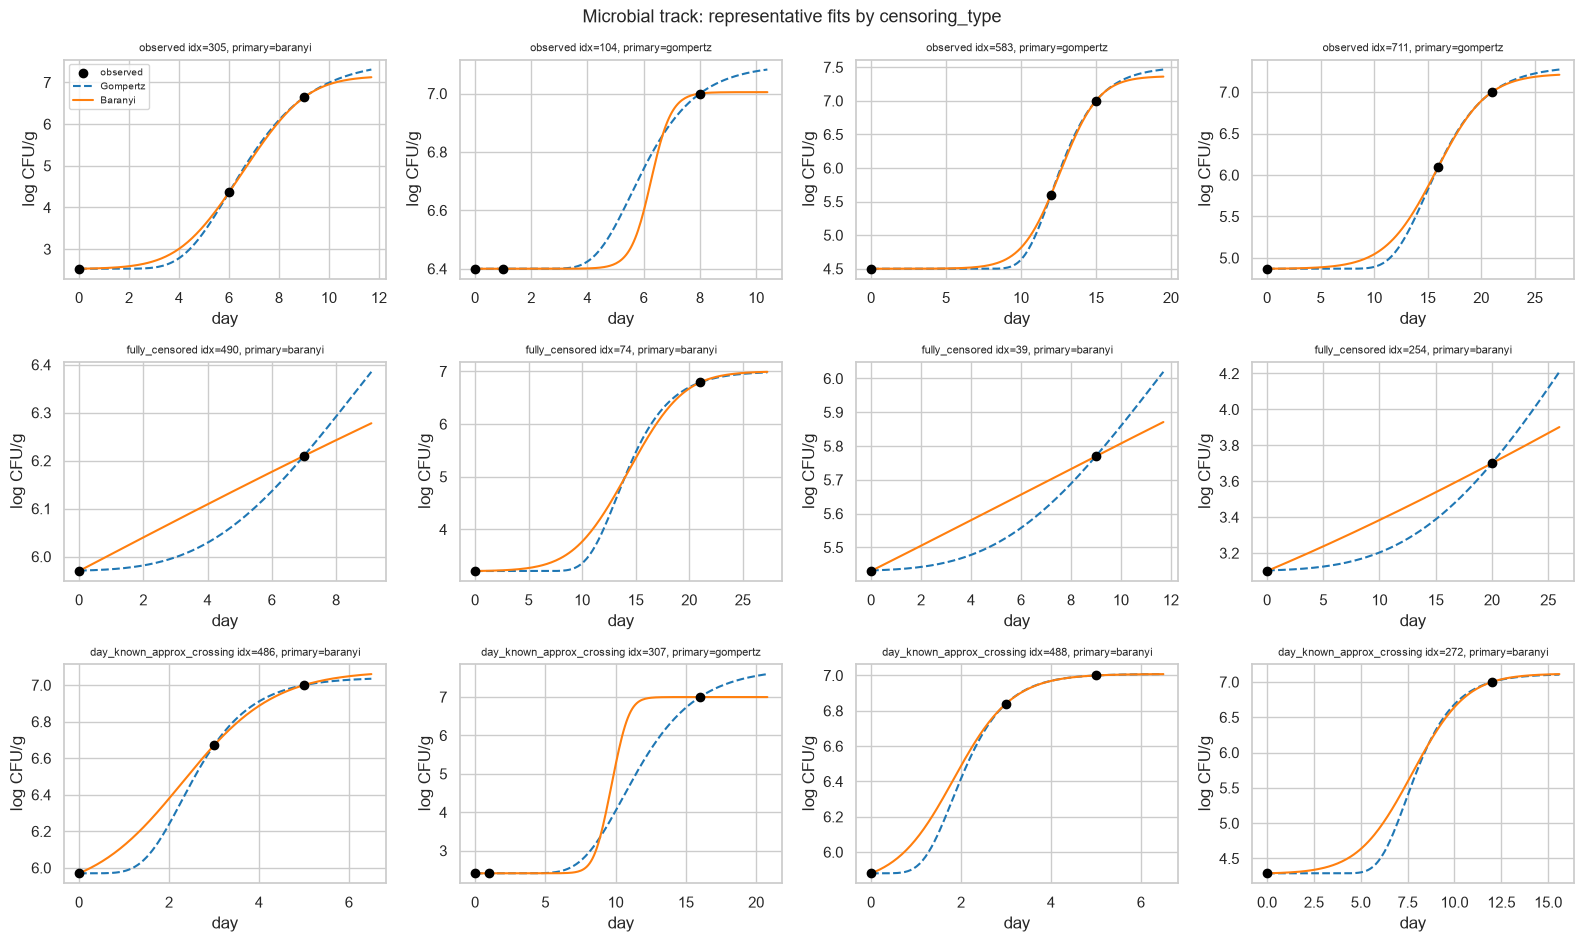

Saved C:\Users\safae\projects\ML\data\processed\figures\microbial_example_fits.png


In [ ]:
def plot_example_fits(df_cls, fits, track, n_per_type=4, seed=RANDOM_STATE):
    joined = df_cls.join(fits, how="left")
    joined = joined[joined["fit_attempted"] == True]
    types = [t for t in joined["censoring_type"].unique() if t in
             ("observed", "day_known_approx_crossing", "fully_censored")]
    fig, axes = plt.subplots(len(types), n_per_type, figsize=(4 * n_per_type, 3.2 * len(types)), squeeze=False)
    rng = np.random.default_rng(seed)
    for i, ctype in enumerate(types):
        subset = joined[joined["censoring_type"] == ctype]
        n_take = min(n_per_type, len(subset))
        sample_idx = rng.choice(subset.index, size=n_take, replace=False)
        for j in range(n_per_type):
            ax = axes[i, j]
            if j >= n_take:
                ax.axis("off")
                continue
            row = joined.loc[sample_idx[j]]
            t_obs, y_obs, _ = extract_points(row)
            y0 = row["initial_count_(day_0)"]
            t_grid = np.linspace(0, max(t_obs.max() * 1.3, 5), 200)
            ax.scatter(t_obs, y_obs, color="black", zorder=5, label="observed")
            if track == "micro":
                if pd.notna(row.get("gompertz_mu_max")):
                    ax.plot(t_grid, gompertz_model(t_grid, y0, row["gompertz_ymax"], row["gompertz_mu_max"], row["gompertz_lag"]), "--", color="tab:blue", label="Gompertz")
                if pd.notna(row.get("baranyi_mu_max")):
                    ax.plot(t_grid, baranyi_model(t_grid, y0, row["baranyi_ymax"], row["baranyi_mu_max"], row["baranyi_lag"]), "-", color="tab:orange", label="Baranyi")
                ax.set_ylabel("log CFU/g")
            else:
                if pd.notna(row.get("zero_order_k")):
                    ax.plot(t_grid, zero_order_model(t_grid, y0, row["zero_order_k"]), "--", color="tab:green", label="zero-order")
                if pd.notna(row.get("first_order_k")):
                    ax.plot(t_grid, first_order_model(t_grid, y0, row["first_order_yceil"], row["first_order_k"]), "-", color="tab:red", label="first-order")
                ax.set_ylabel(row["unit"])
            ax.set_title(f"{ctype} idx={sample_idx[j]}, primary={row['fit_model_used']}", fontsize=8)
            ax.set_xlabel("day")
            if i == 0 and j == 0:
                ax.legend(fontsize=7)
    label = "Microbial" if track == "micro" else "Chemical"
    fig.suptitle(f"{label} track: representative fits by censoring_type", fontsize=13)
    fig.tight_layout()
    out_path = FIG_DIR / f"{label.lower()}_example_fits.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path}")


plot_example_fits(df_micro_cls, micro_fits, "micro")

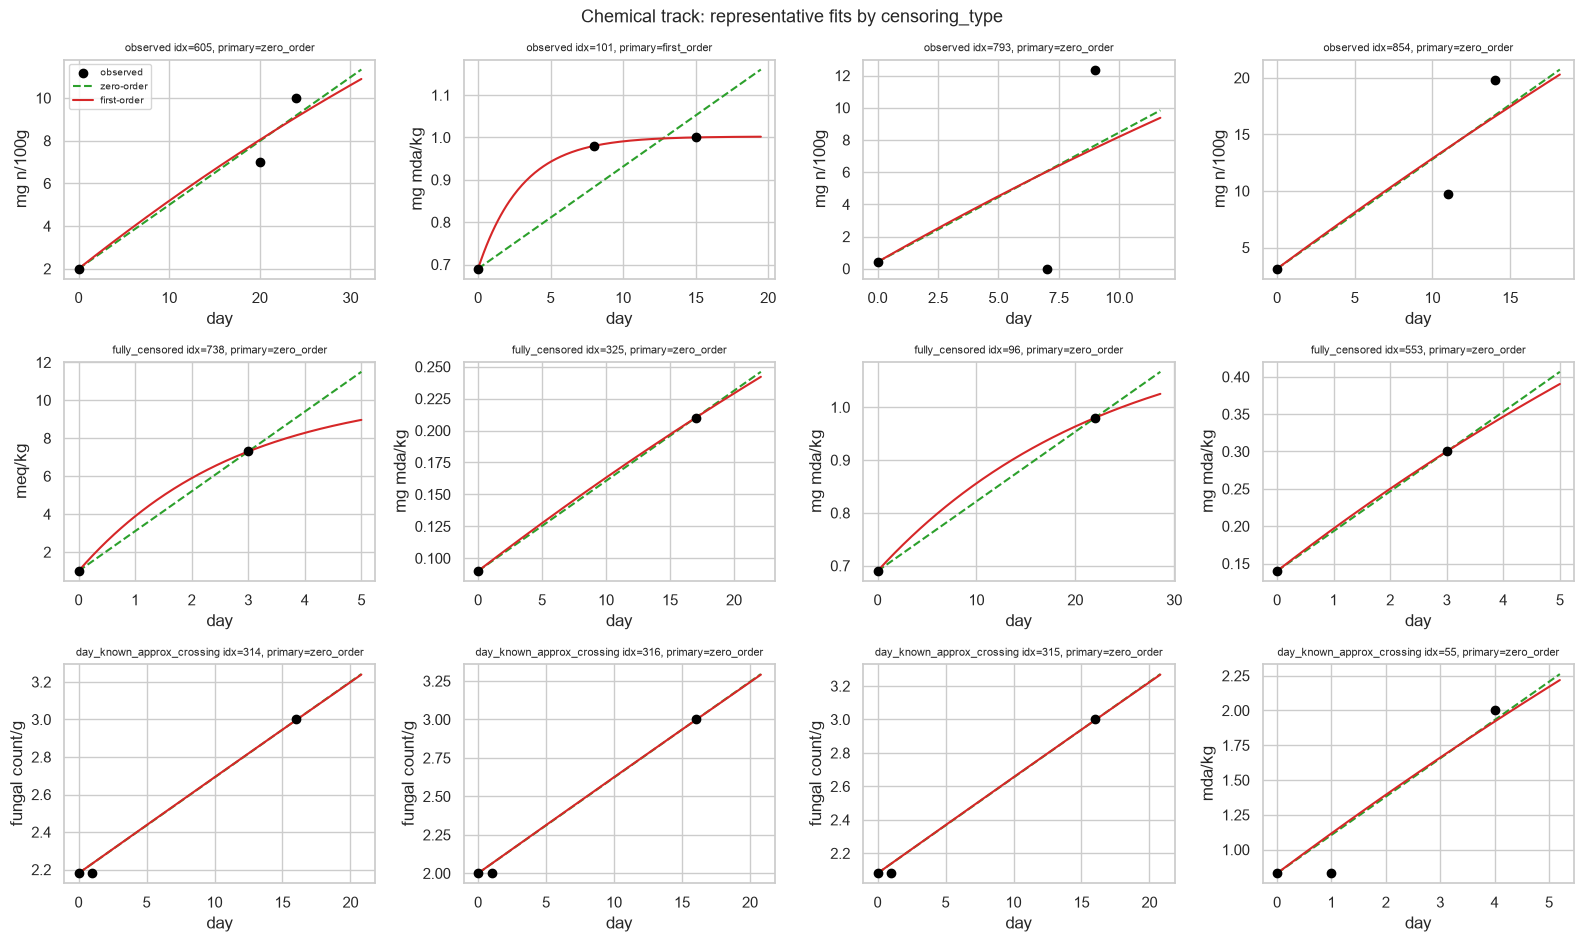

Saved C:\Users\safae\projects\ML\data\processed\figures\chemical_example_fits.png


In [ ]:
plot_example_fits(df_chem_cls, chem_fits, "chem")


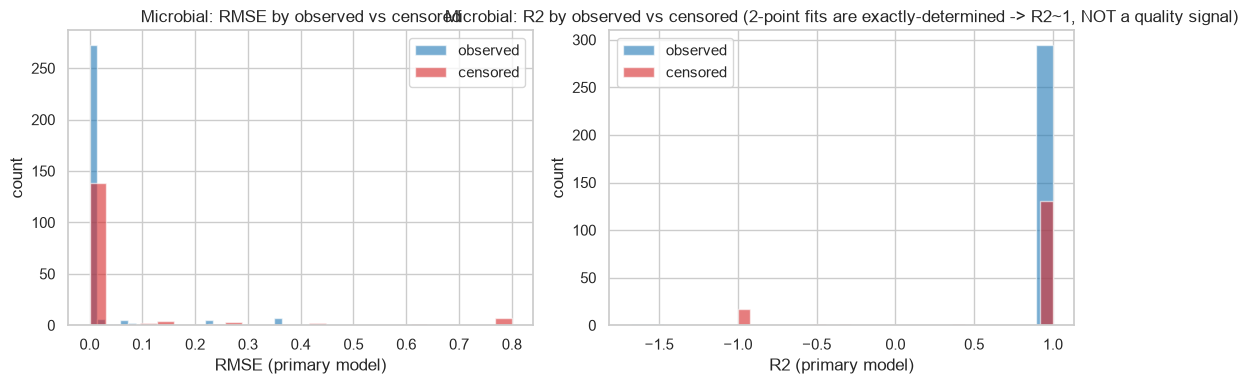

Saved C:\Users\safae\projects\ML\data\processed\figures\microbial_rmse_r2_by_censoring.png


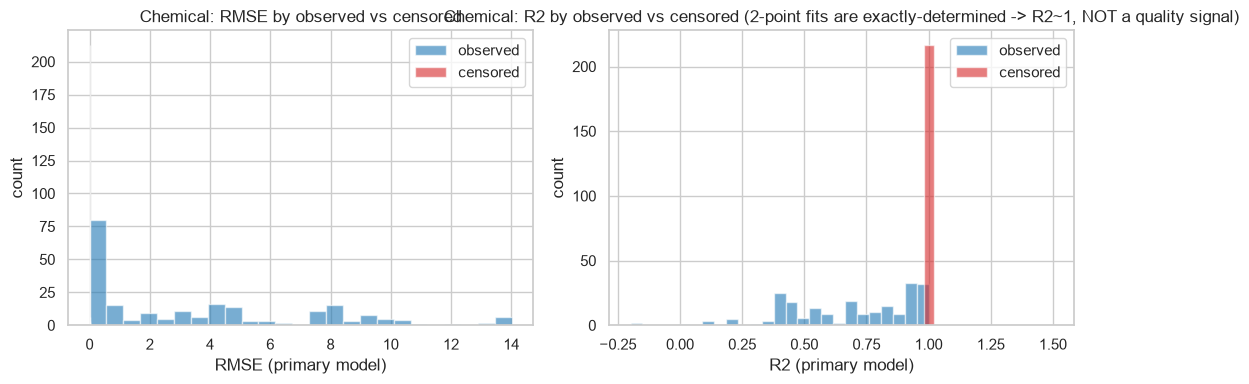

Saved C:\Users\safae\projects\ML\data\processed\figures\chemical_rmse_r2_by_censoring.png


In [ ]:
def plot_rmse_r2_by_censoring(df_cls, fits, track_name):
    joined = df_cls.join(fits, how="left")
    joined = joined[joined["fit_attempted"] == True].copy()

    def primary_rmse(row):
        m = row["fit_model_used"]
        return row[f"{m}_rmse"] if pd.notna(m) else np.nan

    def primary_r2(row):
        m = row["fit_model_used"]
        return row[f"{m}_r2"] if pd.notna(m) else np.nan

    joined["primary_rmse"] = joined.apply(primary_rmse, axis=1)
    joined["primary_r2"] = joined.apply(primary_r2, axis=1)
    joined["group"] = np.where(joined["is_censored"], "censored", "observed")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for grp, color in [("observed", "tab:blue"), ("censored", "tab:red")]:
        sub = joined[joined["group"] == grp]
        cap = sub["primary_rmse"].quantile(0.98) if len(sub) else 1
        axes[0].hist(sub["primary_rmse"].clip(upper=cap), bins=25, alpha=0.6, label=grp, color=color)
        axes[1].hist(sub["primary_r2"].dropna(), bins=25, alpha=0.6, label=grp, color=color)
    axes[0].set(xlabel="RMSE (primary model)", ylabel="count", title=f"{track_name}: RMSE by observed vs censored")
    axes[0].legend()
    r2_title = f"{track_name}: R2 by observed vs censored (2-point fits are exactly-determined -> R2~1, NOT a quality signal)"
    axes[1].set(xlabel="R2 (primary model)", ylabel="count", title=r2_title)
    axes[1].legend()
    fig.tight_layout()
    out_path = FIG_DIR / f"{track_name.lower()}_rmse_r2_by_censoring.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path}")
    return joined


micro_joined_diag = plot_rmse_r2_by_censoring(df_micro_cls, micro_fits, "Microbial")
chem_joined_diag = plot_rmse_r2_by_censoring(df_chem_cls, chem_fits, "Chemical")

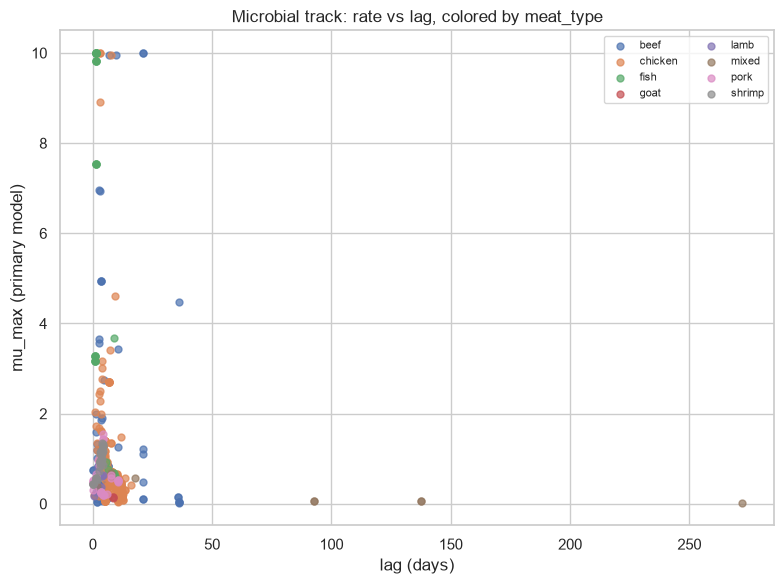

Saved C:\Users\safae\projects\ML\data\processed\figures\microbial_rate_vs_lag_by_meat_type.png


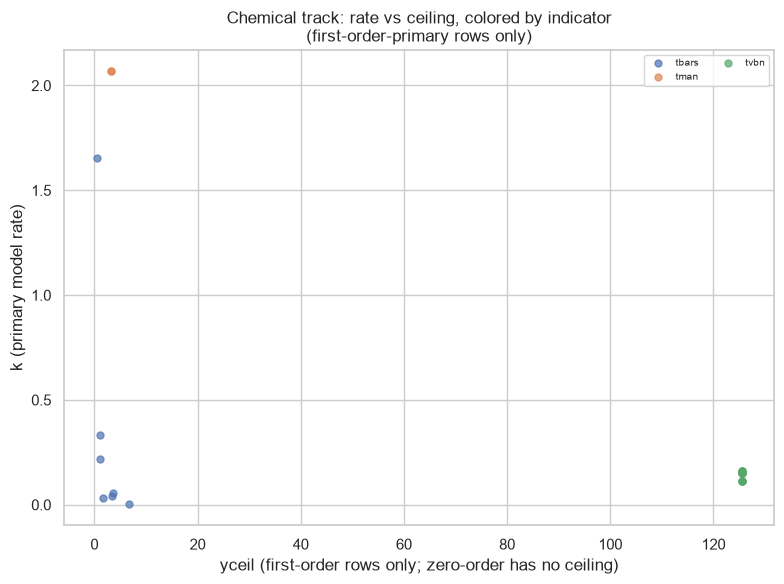

Saved C:\Users\safae\projects\ML\data\processed\figures\chemical_rate_vs_ceiling_by_indicator.png


In [ ]:
def primary_param(row, track):
    m = row["fit_model_used"]
    if pd.isna(m):
        return np.nan, np.nan
    if track == "micro":
        rate = row[f"{m}_mu_max"]
        loc = row[f"{m}_lag"]
    else:
        rate = row["zero_order_k"] if m == "zero_order" else row["first_order_k"]
        loc = np.nan if m == "zero_order" else row["first_order_yceil"]
    return rate, loc


micro_joined_diag[["primary_rate", "primary_lag"]] = micro_joined_diag.apply(
    lambda r: pd.Series(primary_param(r, "micro")), axis=1
)
chem_joined_diag[["primary_rate", "primary_ceiling"]] = chem_joined_diag.apply(
    lambda r: pd.Series(primary_param(r, "chem")), axis=1
)

fig, ax = plt.subplots(figsize=(8, 6))
sub = micro_joined_diag.dropna(subset=["primary_rate", "primary_lag"])
for meat, g in sub.groupby("meat_type"):
    ax.scatter(g["primary_lag"], g["primary_rate"], label=meat, alpha=0.7, s=25)
ax.set_xlabel("lag (days)")
ax.set_ylabel("mu_max (primary model)")
ax.set_title("Microbial track: rate vs lag, colored by meat_type")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
out_path = FIG_DIR / "microbial_rate_vs_lag_by_meat_type.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

fig, ax = plt.subplots(figsize=(8, 6))
sub2 = chem_joined_diag.dropna(subset=["primary_rate"])
sub2_fo = sub2.dropna(subset=["primary_ceiling"])
for ind, g in sub2_fo.groupby("indicators"):
    ax.scatter(g["primary_ceiling"], g["primary_rate"], label=ind, alpha=0.7, s=25)
ax.set_xlabel("yceil (first-order rows only; zero-order has no ceiling)")
ax.set_ylabel("k (primary model rate)")
ax.set_title("Chemical track: rate vs ceiling, colored by indicator\n(first-order-primary rows only)")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
out_path = FIG_DIR / "chemical_rate_vs_ceiling_by_indicator.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## 8. Feature Engineering for ML Regressors

`parse_storage_temperature` handles the messy `storage_condition_(°c)` string column:
plain numbers (`"25"` -> 25.0), `±` uncertainty notation (`"4±1"` -> 4.0 with a separate
`storage_temp_uncertainty` column), `"room temp"` -> the documented constant
`ROOM_TEMP_C = 22.0` (flagged via `storage_temp_source`), ranges (`"21-14"` -> midpoint,
flagged), and a couple of one-off free-text values (`"4c, 8c after d7"`) handled by
taking the first numeric token found and flagging the row as approximate.

In [ ]:
import re

ROOM_TEMP_C = 22.0  # documented constant for "room temp"
STORAGE_TEMP_COL = "storage_condition_(°c)"


def parse_storage_temperature(raw):
    if pd.isna(raw):
        return pd.Series({"storage_temp_numeric": np.nan, "storage_temp_uncertainty": 0.0, "storage_temp_source": "missing"})
    s = str(raw).strip().lower()
    if "room temp" in s:
        return pd.Series({"storage_temp_numeric": ROOM_TEMP_C, "storage_temp_uncertainty": 0.0, "storage_temp_source": "room_temp_constant"})
    m = re.match(r"^(-?\d+(?:\.\d+)?)\s*[±]\s*(\d+(?:\.\d+)?)$", s)
    if m:
        return pd.Series({"storage_temp_numeric": float(m.group(1)), "storage_temp_uncertainty": float(m.group(2)), "storage_temp_source": "plus_minus_parsed"})
    m = re.match(r"^(-?\d+(?:\.\d+)?)\s*[-–]\s*(-?\d+(?:\.\d+)?)$", s)  # hyphen or en-dash
    if m:
        lo, hi = float(m.group(1)), float(m.group(2))
        return pd.Series({"storage_temp_numeric": (lo + hi) / 2, "storage_temp_uncertainty": abs(hi - lo) / 2, "storage_temp_source": "range_midpoint"})
    m = re.match(r"^-?\d+(?:\.\d+)?$", s)
    if m:
        return pd.Series({"storage_temp_numeric": float(s), "storage_temp_uncertainty": 0.0, "storage_temp_source": "direct_numeric"})
    m2 = re.search(r"-?\d+(?:\.\d+)?", s)
    if m2:
        return pd.Series({"storage_temp_numeric": float(m2.group(0)), "storage_temp_uncertainty": np.nan, "storage_temp_source": "free_text_first_token_approx"})
    return pd.Series({"storage_temp_numeric": np.nan, "storage_temp_uncertainty": np.nan, "storage_temp_source": "unparseable"})


_distinct_raw = df_raw[STORAGE_TEMP_COL].dropna().unique()
print("Distinct raw storage_condition values -> parsed result:")
for raw_val in sorted(_distinct_raw, key=str):
    parsed = parse_storage_temperature(raw_val)
    print(f"  {raw_val!r:25s} -> numeric={parsed['storage_temp_numeric']}, uncertainty={parsed['storage_temp_uncertainty']}, source={parsed['storage_temp_source']}")

assert df_raw[STORAGE_TEMP_COL].dropna().apply(lambda v: parse_storage_temperature(v)["storage_temp_source"]).ne("unparseable").all()

Distinct raw storage_condition values -> parsed result:
  '-18'                     -> numeric=-18.0, uncertainty=0.0, source=direct_numeric
  '0'                       -> numeric=0.0, uncertainty=0.0, source=direct_numeric
  '0–2'                     -> numeric=1.0, uncertainty=1.0, source=range_midpoint
  '20'                      -> numeric=20.0, uncertainty=0.0, source=direct_numeric
  '21-14'                   -> numeric=17.5, uncertainty=3.5, source=range_midpoint
  '25'                      -> numeric=25.0, uncertainty=0.0, source=direct_numeric
  '4'                       -> numeric=4.0, uncertainty=0.0, source=direct_numeric
  '4c, 8c after d7'         -> numeric=4.0, uncertainty=nan, source=free_text_first_token_approx
  '4c, 8c after d8'         -> numeric=4.0, uncertainty=nan, source=free_text_first_token_approx
  '4±1'                     -> numeric=4.0, uncertainty=1.0, source=plus_minus_parsed
  '5'                       -> numeric=5.0, uncertainty=0.0, source=direct_num

In [ ]:
CATEGORICAL_FEATURES = [
    "meat_type", "indicators", "ingredient", "packaging_class", "physical_hurdle_tech",
    "application_method", "hurdle_coordination", "part_of_product",
]
NUMERIC_FEATURES = [
    "concentration", "storage_temp_numeric", "irradiation_dose", "immersion_time",
    "gas_CO2", "gas_O2", "lower_level_threshold_(log_cfu/g)", "upper_level_threshold_(log_cfu/g)",
]
ALL_FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES


def build_feature_frame(df):
    feat = df.copy()
    temp_parsed = feat[STORAGE_TEMP_COL].apply(parse_storage_temperature)
    feat = pd.concat([feat, temp_parsed], axis=1)
    for c in CATEGORICAL_FEATURES:
        feat[c] = feat[c].astype("object").fillna("__missing__")
    return feat


micro_features = build_feature_frame(micro_joined_diag)
chem_features = build_feature_frame(chem_joined_diag)
micro_features_full = build_feature_frame(df_micro_cls.join(micro_fits, how="left"))
chem_features_full = build_feature_frame(df_chem_cls.join(chem_fits, how="left"))

print(f"Microbial feature frame: {micro_features.shape}")
print(f"Chemical feature frame: {chem_features.shape}")
print("\nFeature columns used:", ALL_FEATURES)

Microbial feature frame: (460, 70)
Chemical feature frame: (450, 65)

Feature columns used: ['meat_type', 'indicators', 'ingredient', 'packaging_class', 'physical_hurdle_tech', 'application_method', 'hurdle_coordination', 'part_of_product', 'concentration', 'storage_temp_numeric', 'irradiation_dose', 'immersion_time', 'gas_CO2', 'gas_O2', 'lower_level_threshold_(log_cfu/g)', 'upper_level_threshold_(log_cfu/g)']


**Circularity guard**: ML training labels come only from `"observed"` and
`"day_known_approx_crossing"` rows (both are effectively "observed" per Decision 2) —
never from `"fully_censored"` fitted values, since those are themselves estimates the
predictor would later be asked to reconstruct. Enforced with an explicit `assert`, not
just a comment.

In [ ]:
TRAINABLE_TYPES = ("observed", "day_known_approx_crossing")

micro_trainable = micro_features[micro_features["censoring_type"].isin(TRAINABLE_TYPES)].copy()
chem_trainable = chem_features[chem_features["censoring_type"].isin(TRAINABLE_TYPES)].copy()

assert micro_trainable["censoring_type"].isin(TRAINABLE_TYPES).all()
assert not (micro_trainable["censoring_type"] == "fully_censored").any()
assert chem_trainable["censoring_type"].isin(TRAINABLE_TYPES).all()
assert not (chem_trainable["censoring_type"] == "fully_censored").any()

micro_trainable["y_rate"] = micro_trainable["primary_rate"]
micro_trainable["y_lag"] = micro_trainable["primary_lag"]
micro_trainable = micro_trainable.dropna(subset=["y_rate", "y_lag"])

chem_trainable["y_rate"] = chem_trainable["primary_rate"]
chem_trainable_ceiling = chem_trainable.dropna(subset=["primary_ceiling"]).copy()
chem_trainable_rate = chem_trainable.dropna(subset=["y_rate"]).copy()

print(f"Microbial trainable rows (rate & lag labels): {len(micro_trainable)}")
print(f"Chemical trainable rows (rate label): {len(chem_trainable_rate)}")
print(f"Chemical trainable rows (ceiling label, first-order-primary only): {len(chem_trainable_ceiling)}")


Microbial trainable rows (rate & lag labels): 302
Chemical trainable rows (rate label): 224
Chemical trainable rows (ceiling label, first-order-primary only): 21


## 9. GPR vs RFR Comparison

Per track/target: `build_gpr_pipeline()` (one-hot + GPR, `Constant*Matern(nu=2.5)+WhiteKernel`)
vs `build_rfr_pipeline()` (ordinal-encode + RandomForest). Cross-validated with
`RepeatedKFold`, benchmarked against a trivial per-group-mean baseline.

**Deviation from the general plan**: the chemical ceiling target has only 5 trainable
rows (first-order-primary AND observed/approx) — too few for CV. We skip a learned
chemical ceiling predictor and reconstruct those rows via the point-estimate `ymax_hat`
procedure (Decision 14b) instead.

In [ ]:
def build_gpr_pipeline():
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ])
    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(1.0, (1e-5, 1e2))
    gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=RANDOM_STATE, n_restarts_optimizer=2)
    return Pipeline([("pre", pre), ("gpr", gpr)])


def build_rfr_pipeline():
    pre = ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CATEGORICAL_FEATURES),
        ("num", "passthrough", NUMERIC_FEATURES),
    ])
    rfr = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300)
    return Pipeline([("pre", pre), ("rfr", rfr)])


def numeric_medians(df):
    """Per-column medians of NUMERIC_FEATURES, with a 0.0 fallback for any column that is
    entirely NaN within `df` (median would be NaN otherwise -- happens for some chemical-track
    threshold columns). Single definition of the numeric-imputation reference used at BOTH
    training time (build_imputer_frame) and reconstruction/inference time, so the two never
    diverge."""
    return {c: (m if pd.notna(m := df[c].median()) else 0.0) for c in NUMERIC_FEATURES}


def fill_numeric(df, medians):
    """Fill NUMERIC_FEATURES NaNs from a precomputed medians dict (see numeric_medians)."""
    out = df.copy()
    for c in NUMERIC_FEATURES:
        out[c] = out[c].fillna(medians[c])
    return out


def build_imputer_frame(df):
    """Fill numeric-feature NaNs with this frame's own column medians so GPR/RFR never see
    raw NaN (categoricals already use the "__missing__" token from build_feature_frame)."""
    return fill_numeric(df, numeric_medians(df))


print("build_gpr_pipeline / build_rfr_pipeline / numeric_medians / fill_numeric / build_imputer_frame defined")

# Numeric-imputation reference captured from the exact trainable frames the GPR/RFR pipelines
# are fit on (Section 9, next). Reused verbatim at reconstruction/inference time (Sections
# 10-11) so rows with missing numeric features are imputed the SAME way they were during
# training -- previously inference filled these with 0.0, a train/inference mismatch that
# biased the predicted rate/lag for any row missing a numeric feature.
MICRO_NUMERIC_MEDIANS = numeric_medians(micro_trainable)
CHEM_NUMERIC_MEDIANS = numeric_medians(chem_trainable_rate)

build_gpr_pipeline / build_rfr_pipeline / build_imputer_frame defined


In [ ]:
def group_mean_baseline_cv(X, y, group_col, n_splits, n_repeats, seed):
    # Trivial baseline: per-group (e.g. meat_type) training-fold mean, falling back
    # to the training fold's global mean for unseen groups.
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    r2s, rmses, maes = [], [], []
    groups = X[group_col].values
    y = np.asarray(y)
    for train_idx, test_idx in rkf.split(X):
        train_y = pd.Series(y[train_idx])
        group_means = train_y.groupby(pd.Series(groups[train_idx]).values).mean()
        preds = pd.Series(groups[test_idx]).map(group_means).fillna(train_y.mean()).values
        r2s.append(r2_score(y[test_idx], preds))
        rmses.append(np.sqrt(mean_squared_error(y[test_idx], preds)))
        maes.append(mean_absolute_error(y[test_idx], preds))
    return {"r2_mean": np.mean(r2s), "r2_std": np.std(r2s), "rmse_mean": np.mean(rmses),
            "rmse_std": np.std(rmses), "mae_mean": np.mean(maes), "mae_std": np.std(maes)}


def evaluate_model_cv(pipeline, X, y, n_splits, n_repeats, seed):
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    scoring = {"r2": "r2", "rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}
    cv_res = cross_validate(pipeline, X, y, cv=rkf, scoring=scoring, n_jobs=1)
    return {"r2_mean": cv_res["test_r2"].mean(), "r2_std": cv_res["test_r2"].std(),
            "rmse_mean": -cv_res["test_rmse"].mean(), "rmse_std": cv_res["test_rmse"].std(),
            "mae_mean": -cv_res["test_mae"].mean(), "mae_std": cv_res["test_mae"].std()}


def choose_n_splits(n_rows, min_per_fold=15, max_splits=5):
    return min(max_splits, max(2, n_rows // min_per_fold))


print("group_mean_baseline_cv / evaluate_model_cv / choose_n_splits defined")

group_mean_baseline_cv / evaluate_model_cv / choose_n_splits defined


In [ ]:
N_REPEATS = 10

targets = {
    ("microbial", "rate"): (micro_trainable, "y_rate", "meat_type"),
    ("microbial", "lag"): (micro_trainable, "y_lag", "meat_type"),
    ("chemical", "rate"): (chem_trainable_rate, "y_rate", "indicators"),
}

cv_summary_rows = []
fitted_pipelines = {}

for (track, target_name), (data, ycol, group_col) in targets.items():
    data_imp = build_imputer_frame(data)
    X = data_imp[ALL_FEATURES + [group_col]] if group_col not in ALL_FEATURES else data_imp[ALL_FEATURES]
    y = data_imp[ycol].values
    n_splits = choose_n_splits(len(data_imp))
    print(f"\n=== {track} / {target_name}: n={len(data_imp)}, n_splits={n_splits}, n_repeats={N_REPEATS} ===")

    baseline = group_mean_baseline_cv(X, y, group_col, n_splits, N_REPEATS, RANDOM_STATE)
    gpr_res = evaluate_model_cv(build_gpr_pipeline(), X[ALL_FEATURES], y, n_splits, N_REPEATS, RANDOM_STATE)
    rfr_res = evaluate_model_cv(build_rfr_pipeline(), X[ALL_FEATURES], y, n_splits, N_REPEATS, RANDOM_STATE)

    for model_name, res in [("baseline_group_mean", baseline), ("GPR", gpr_res), ("RFR", rfr_res)]:
        cv_summary_rows.append({"track": track, "target": target_name, "model": model_name,
            "n_rows": len(data_imp), "n_splits": n_splits, **{f"{k}": v for k, v in res.items()}})
        print(f"  {model_name:20s} R2={res['r2_mean']:.3f}+/-{res['r2_std']:.3f}  "
              f"RMSE={res['rmse_mean']:.4f}+/-{res['rmse_std']:.4f}  MAE={res['mae_mean']:.4f}+/-{res['mae_std']:.4f}")

    winner = "GPR" if gpr_res["r2_mean"] >= rfr_res["r2_mean"] else "RFR"
    print(f"  --> winner for {track}/{target_name}: {winner}")

    winning_pipeline = build_gpr_pipeline() if winner == "GPR" else build_rfr_pipeline()
    winning_pipeline.fit(X[ALL_FEATURES], y)
    fitted_pipelines[(track, target_name)] = (winner, winning_pipeline)

    model_path = MODELS_DIR / f"{track}_{target_name}_predictor.joblib"
    joblib.dump(winning_pipeline, model_path)
    print(f"  Saved winning ({winner}) pipeline to {model_path}")

cv_summary = pd.DataFrame(cv_summary_rows)
cv_summary.to_csv(PROC_DIR / "gpr_vs_rfr_cv_summary.csv", index=False)
cv_summary


=== microbial / rate: n=302, n_splits=5, n_repeats=10 ===


  baseline_group_mean  R2=0.330+/-0.366  RMSE=1.7361+/-0.3200  MAE=0.9995+/-0.1618
  GPR                  R2=0.543+/-0.191  RMSE=1.4611+/-0.3345  MAE=0.7832+/-0.1325
  RFR                  R2=0.505+/-0.227  RMSE=1.5120+/-0.3316  MAE=0.7606+/-0.1446
  --> winner for microbial/rate: GPR


  Saved winning (GPR) pipeline to C:\Users\safae\projects\ML\data\processed\models\microbial_rate_predictor.joblib

=== microbial / lag: n=302, n_splits=5, n_repeats=10 ===


  baseline_group_mean  R2=0.281+/-0.129  RMSE=2.7466+/-0.4117  MAE=2.0631+/-0.2630
  GPR                  R2=0.510+/-0.128  RMSE=2.2617+/-0.4425  MAE=1.4832+/-0.2463
  RFR                  R2=0.541+/-0.126  RMSE=2.1865+/-0.4188  MAE=1.4231+/-0.2515
  --> winner for microbial/lag: RFR


  Saved winning (RFR) pipeline to C:\Users\safae\projects\ML\data\processed\models\microbial_lag_predictor.joblib

=== chemical / rate: n=224, n_splits=5, n_repeats=10 ===


  baseline_group_mean  R2=0.145+/-0.180  RMSE=1.8779+/-0.4130  MAE=0.9876+/-0.1884
  GPR                  R2=0.560+/-0.478  RMSE=1.2534+/-0.3623  MAE=0.6382+/-0.1511
  RFR                  R2=0.557+/-0.537  RMSE=1.2195+/-0.4575  MAE=0.5501+/-0.1602
  --> winner for chemical/rate: GPR


  Saved winning (GPR) pipeline to C:\Users\safae\projects\ML\data\processed\models\chemical_rate_predictor.joblib


,track,target,model,n_rows,n_splits,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std
0,microbial,rate,baseline_group_mean,302,5,0.330200,0.365682,1.736126,0.320021,0.999504,0.161796
1,microbial,rate,GPR,302,5,0.543148,0.190618,1.461129,0.334541,0.783162,0.132519
2,microbial,rate,RFR,302,5,0.504599,0.226687,1.511980,0.331561,0.760588,0.144640
3,microbial,lag,baseline_group_mean,302,5,0.280788,0.128578,2.746598,0.411731,2.063086,0.263010
4,microbial,lag,GPR,302,5,0.510336,0.127717,2.261738,0.442468,1.483204,0.246335
5,microbial,lag,RFR,302,5,0.540994,0.125673,2.186464,0.418848,1.423109,0.251523
6,chemical,rate,baseline_group_mean,224,5,0.145432,0.180481,1.877930,0.413008,0.987609,0.188394
7,chemical,rate,GPR,224,5,0.559630,0.477755,1.253401,0.362265,0.638171,0.151064
8,chemical,rate,RFR,224,5,0.557244,0.536590,1.219548,0.457549,0.550089,0.160160


In [ ]:
def get_feature_names(pipeline):
    return pipeline.named_steps["pre"].get_feature_names_out()


for (track, target_name), (winner, pipeline) in fitted_pipelines.items():
    data, ycol, group_col = targets[(track, target_name)]
    data_imp = build_imputer_frame(data)
    X = data_imp[ALL_FEATURES]
    y = data_imp[ycol].values

    if winner == "RFR":
        feat_names = get_feature_names(pipeline)
        importances = pipeline.named_steps["rfr"].feature_importances_
    else:
        # permutation_importance shuffles *input* columns (pre-encoding), so importances
        # align with ALL_FEATURES, not the one-hot-expanded get_feature_names_out() names.
        feat_names = ALL_FEATURES
        perm = permutation_importance(pipeline, X, y, n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)
        importances = perm.importances_mean

    imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False)
    print(f"\nTop 8 feature importances for {track}/{target_name} ({winner}):")
    print(imp_df.head(8).to_string(index=False))


Top 8 feature importances for microbial/rate (GPR):
             feature  importance
storage_temp_numeric    0.515138
     part_of_product    0.232978
           meat_type    0.158939
          indicators    0.152168
          ingredient    0.141175
     packaging_class    0.129499
 hurdle_coordination    0.087804
  application_method    0.074684

Top 8 feature importances for microbial/lag (RFR):
                               feature  importance
                  cat__part_of_product    0.228082
                    num__concentration    0.158813
                        cat__meat_type    0.146841
                  cat__packaging_class    0.108073
                       cat__indicators    0.100830
               cat__application_method    0.085744
                       cat__ingredient    0.079873
num__upper_level_threshold_(log_cfu/g)    0.018579



Top 8 feature importances for chemical/rate (GPR):
                          feature  importance
             storage_temp_numeric    0.208550
lower_level_threshold_(log_cfu/g)    0.137790
              hurdle_coordination    0.124162
               application_method    0.110209
                       ingredient    0.081937
upper_level_threshold_(log_cfu/g)    0.081567
                        meat_type    0.037594
                  part_of_product    0.037491


## 10. Reconstruction of Censored Rows

For `fully_censored` (fit_feasible) rows: predict rate/lag-or-ceiling from the saved ML
models, plug into the model function with fixed y0 and a point-estimate `ymax_hat`, then
root-find (`scipy.optimize.brentq`) the day where the curve crosses `upper_threshold`.
`missing_y0`/`underdetermined_single_point` rows use ML-only prediction with a
group-median y0 fallback, flagged lower-confidence. Chemical ceiling reconstruction uses
the point-estimate procedure (Section 9's documented deviation), not a learned model.

In [ ]:
def compute_ymax_hat_stats(fits_df, cls_df, ceiling_col, upper_col="upper_level_threshold_(log_cfu/g)"):
    joined = cls_df.join(fits_df, how="left")
    observed = joined[joined["censoring_type"] == "observed"]
    gaps = []
    for _, row in observed.iterrows():
        m = row.get("fit_model_used")
        if pd.isna(m):
            continue
        ymax_col = f"{m}_{ceiling_col}" if ceiling_col != "ymax" else f"{m}_ymax"
        if ymax_col in row and pd.notna(row[ymax_col]) and pd.notna(row.get(upper_col)):
            gaps.append(row[ymax_col] - row[upper_col])
    return float(np.median(gaps)) if gaps else 0.5


MICRO_YMAX_HAT_MARGIN = compute_ymax_hat_stats(micro_fits, df_micro_cls, "ymax")
print(f"Microbial median(fitted_ymax - upper_threshold) on observed rows: {MICRO_YMAX_HAT_MARGIN:.3f}")

CHEM_YCEIL_HAT_MARGIN = compute_ymax_hat_stats(chem_fits, df_chem_cls, "yceil")
print(f"Chemical median(fitted_yceil - upper_threshold) on observed first-order rows: {CHEM_YCEIL_HAT_MARGIN:.3f}")

Microbial median(fitted_ymax - upper_threshold) on observed rows: 0.247
Chemical median(fitted_yceil - upper_threshold) on observed first-order rows: 95.480


In [ ]:
def reconstruct_row_microbial(row, fits_row, rate_pipeline, lag_pipeline, ymax_hat_margin, t_max_window):
    y0 = row["initial_count_(day_0)"]
    if pd.isna(y0):
        return {"reconstruction_status": "missing_y0_no_fallback_here"}
    feat_row = fill_numeric(pd.DataFrame([row[ALL_FEATURES]]), MICRO_NUMERIC_MEDIANS)
    rate_hat = rate_pipeline.predict(feat_row)[0]
    lag_hat = lag_pipeline.predict(feat_row)[0]
    upper = row["upper_level_threshold_(log_cfu/g)"]
    if pd.isna(upper):
        return {"reconstruction_status": "no_threshold_available"}
    ymax_hat = upper + ymax_hat_margin
    model_fn = gompertz_model if fits_row.get("fit_model_used") == "gompertz" else baranyi_model

    def f(t):
        return model_fn(np.array([t]), y0, ymax_hat, rate_hat, lag_hat)[0] - upper

    lo, hi = 0.0, t_max_window
    if f(lo) >= 0:
        return {"reconstruction_status": "already_above_threshold_at_day0", "rate_hat": rate_hat, "lag_hat": lag_hat, "ymax_hat": ymax_hat}
    if f(hi) < 0:
        return {"reconstruction_status": "no_crossing_within_window", "rate_hat": rate_hat, "lag_hat": lag_hat, "ymax_hat": ymax_hat}
    t_star = brentq(f, lo, hi)
    y_star = model_fn(np.array([t_star]), y0, ymax_hat, rate_hat, lag_hat)[0]
    return {"reconstruction_status": "reconstructed", "rate_hat": rate_hat, "lag_hat": lag_hat,
            "ymax_hat": ymax_hat, "post_day_reconstructed": t_star, "post_count_reconstructed": y_star}


print("reconstruct_row_microbial defined")

reconstruct_row_microbial defined


In [ ]:
micro_rate_pipeline = fitted_pipelines[("microbial", "rate")][1]
micro_lag_pipeline = fitted_pipelines[("microbial", "lag")][1]

MICRO_T_MAX_WINDOW = max(90.0, 2 * micro_features_full["post_threshold_(day)"].max(skipna=True))
print(f"Microbial reconstruction search window: [0, {MICRO_T_MAX_WINDOW:.1f}] days")

_micro_group_median_y0 = df_micro_cls.groupby("meat_type")["initial_count_(day_0)"].median()
_micro_global_median_y0 = df_micro_cls["initial_count_(day_0)"].median()

micro_recon_records = []
for idx, row in micro_features_full.iterrows():
    rec = {"index": idx, "censoring_type": row["censoring_type"]}
    if row["censoring_type"] == "fully_censored" and row["fit_feasible"]:
        result = reconstruct_row_microbial(row, row, micro_rate_pipeline, micro_lag_pipeline,
                                            MICRO_YMAX_HAT_MARGIN, MICRO_T_MAX_WINDOW)
        rec.update(result)
        rec["data_completeness_status"] = "censored_reconstructed" if result.get("reconstruction_status") == "reconstructed" else "censored_unreconstructed"
    elif row["censoring_type"] in ("missing_y0", "underdetermined_single_point"):
        y0_fallback = _micro_group_median_y0.get(row.get("meat_type"), _micro_global_median_y0)
        row_filled = row.copy()
        row_filled["initial_count_(day_0)"] = y0_fallback if pd.isna(row["initial_count_(day_0)"]) else row["initial_count_(day_0)"]
        result = reconstruct_row_microbial(row_filled, row, micro_rate_pipeline, micro_lag_pipeline,
                                            MICRO_YMAX_HAT_MARGIN, MICRO_T_MAX_WINDOW)
        result["y0_source"] = "group_median_fallback" if pd.isna(row["initial_count_(day_0)"]) else "observed"
        rec.update(result)
        rec["data_completeness_status"] = "missing_y0_excluded" if row["censoring_type"] == "missing_y0" else (
            "censored_reconstructed" if result.get("reconstruction_status") == "reconstructed" else "censored_unreconstructed")
    else:
        rec["data_completeness_status"] = "observed"
    micro_recon_records.append(rec)

micro_recon = pd.DataFrame(micro_recon_records).set_index("index")
print(micro_recon["data_completeness_status"].value_counts(dropna=False))
if "reconstruction_status" in micro_recon.columns:
    print(micro_recon["reconstruction_status"].value_counts(dropna=False))

Microbial reconstruction search window: [0, 90.0] days


data_completeness_status
observed                    302
censored_reconstructed      140
censored_unreconstructed     22
missing_y0_excluded          12
Name: count, dtype: int64
reconstruction_status
NaN                                302
reconstructed                      152
already_above_threshold_at_day0     18
no_threshold_available               4
Name: count, dtype: int64


In [ ]:
micro_reconstructed = df_micro_cls.join(micro_recon, how="left", rsuffix="_recon")
micro_reconstructed.to_csv(PROC_DIR / "microbial_rows_reconstructed.csv", index=False)
print(f"Saved {PROC_DIR / 'microbial_rows_reconstructed.csv'}: {len(micro_reconstructed)} rows")

n_recon = (micro_recon["data_completeness_status"] == "censored_reconstructed").sum()
n_unrecon = (micro_recon["data_completeness_status"] == "censored_unreconstructed").sum()
print(f"Microbial: {n_recon} rows reconstructed, {n_unrecon} left censored_unreconstructed")

Saved C:\Users\safae\projects\ML\data\processed\microbial_rows_reconstructed.csv: 476 rows
Microbial: 140 rows reconstructed, 22 left censored_unreconstructed


In [ ]:
def reconstruct_row_chemical(row, fits_row, rate_pipeline, yceil_hat_margin, t_max_window):
    y0 = row["initial_count_(day_0)"]
    if pd.isna(y0):
        return {"reconstruction_status": "missing_y0_no_fallback_here"}
    feat_row = fill_numeric(pd.DataFrame([row[ALL_FEATURES]]), CHEM_NUMERIC_MEDIANS)
    rate_hat = rate_pipeline.predict(feat_row)[0]
    upper = row["upper_level_threshold_(log_cfu/g)"]
    if pd.isna(upper):
        return {"reconstruction_status": "no_threshold_available"}
    primary = fits_row.get("fit_model_used")

    if primary == "zero_order" or pd.isna(primary):
        if abs(rate_hat) < 1e-12:
            return {"reconstruction_status": "no_crossing_within_window", "rate_hat": rate_hat}
        t_star = (upper - y0) / rate_hat
        if t_star < 0 or t_star > t_max_window:
            return {"reconstruction_status": "no_crossing_within_window", "rate_hat": rate_hat}
        y_star = zero_order_model(np.array([t_star]), y0, rate_hat)[0]
        return {"reconstruction_status": "reconstructed", "rate_hat": rate_hat,
                "post_day_reconstructed": t_star, "post_count_reconstructed": y_star}

    yceil_hat = upper + yceil_hat_margin

    def f(t):
        return first_order_model(np.array([t]), y0, yceil_hat, rate_hat)[0] - upper

    lo, hi = 0.0, t_max_window
    if f(lo) >= 0:
        return {"reconstruction_status": "already_above_threshold_at_day0", "rate_hat": rate_hat, "yceil_hat": yceil_hat}
    if f(hi) < 0:
        return {"reconstruction_status": "no_crossing_within_window", "rate_hat": rate_hat, "yceil_hat": yceil_hat}
    t_star = brentq(f, lo, hi)
    y_star = first_order_model(np.array([t_star]), y0, yceil_hat, rate_hat)[0]
    return {"reconstruction_status": "reconstructed", "rate_hat": rate_hat, "yceil_hat": yceil_hat,
            "post_day_reconstructed": t_star, "post_count_reconstructed": y_star}


print("reconstruct_row_chemical defined")

reconstruct_row_chemical defined


In [ ]:
chem_rate_pipeline = fitted_pipelines[("chemical", "rate")][1]

CHEM_T_MAX_WINDOW = max(90.0, 2 * chem_joined_diag["post_threshold_(day)"].max(skipna=True))
print(f"Chemical reconstruction search window: [0, {CHEM_T_MAX_WINDOW:.1f}] days")

_chem_group_median_y0 = df_chem_cls.groupby("indicators")["initial_count_(day_0)"].median()
_chem_global_median_y0 = df_chem_cls["initial_count_(day_0)"].median()

chem_recon_records = []
for idx, row in chem_features_full.iterrows():
    rec = {"index": idx, "censoring_type": row["censoring_type"]}
    if row["censoring_type"] == "fully_censored" and row["fit_feasible"]:
        result = reconstruct_row_chemical(row, row, chem_rate_pipeline, CHEM_YCEIL_HAT_MARGIN, CHEM_T_MAX_WINDOW)
        rec.update(result)
        rec["data_completeness_status"] = "censored_reconstructed" if result.get("reconstruction_status") == "reconstructed" else "censored_unreconstructed"
    elif row["censoring_type"] == "missing_y0":
        y0_fallback = _chem_group_median_y0.get(row.get("indicators"), _chem_global_median_y0)
        row_filled = row.copy()
        row_filled["initial_count_(day_0)"] = y0_fallback
        result = reconstruct_row_chemical(row_filled, row, chem_rate_pipeline, CHEM_YCEIL_HAT_MARGIN, CHEM_T_MAX_WINDOW)
        result["y0_source"] = "group_median_fallback"
        rec.update(result)
        rec["data_completeness_status"] = "missing_y0_excluded"
    else:
        rec["data_completeness_status"] = "observed"
    chem_recon_records.append(rec)

chem_recon = pd.DataFrame(chem_recon_records).set_index("index")
print(chem_recon["data_completeness_status"].value_counts(dropna=False))
if "reconstruction_status" in chem_recon.columns:
    print(chem_recon["reconstruction_status"].value_counts(dropna=False))

Chemical reconstruction search window: [0, 120.0] days


data_completeness_status
observed                    224
censored_reconstructed      224
missing_y0_excluded          38
censored_unreconstructed      2
Name: count, dtype: int64
reconstruction_status
reconstructed                  256
NaN                            224
missing_y0_no_fallback_here      6
no_threshold_available           2
Name: count, dtype: int64


In [ ]:
chem_reconstructed = df_chem_cls.join(chem_recon, how="left", rsuffix="_recon")
chem_reconstructed.to_csv(PROC_DIR / "chemical_rows_reconstructed.csv", index=False)
print(f"Saved {PROC_DIR / 'chemical_rows_reconstructed.csv'}: {len(chem_reconstructed)} rows")

n_recon_c = (chem_recon["data_completeness_status"] == "censored_reconstructed").sum()
n_unrecon_c = (chem_recon["data_completeness_status"] == "censored_unreconstructed").sum()
print(f"Chemical: {n_recon_c} rows reconstructed, {n_unrecon_c} left censored_unreconstructed")

Saved C:\Users\safae\projects\ML\data\processed\chemical_rows_reconstructed.csv: 488 rows
Chemical: 224 rows reconstructed, 2 left censored_unreconstructed


## 11. Held-Out Validation (the credibility check)

**This is the most important verification in the notebook.** Real `fully_censored` rows
have no known ground truth to compare against. But `"observed"` (fully 3-point) rows
DO have a known post_threshold value we can artificially hide: refit on
`(day0, pre_threshold)` only, predict forward with the SAME reconstruction procedure as
Section 10, and compare against the real (held-out) post_threshold. This is the only
rigorous, ground-truth-based estimate of how good the reconstruction method actually is.

In [ ]:
def held_out_validation_micro(df_cls, fits, rate_pipeline, lag_pipeline, ymax_hat_margin, t_max_window):
    observed = df_cls[df_cls["censoring_type"] == "observed"].join(fits, how="left")
    observed = build_feature_frame(observed)
    records = []
    for idx, row in observed.iterrows():
        y0 = row["initial_count_(day_0)"]
        if pd.isna(y0) or pd.isna(row["pre_threshold_(day)"]) or pd.isna(row["pre_threshold_count"]):
            continue
        t_obs = np.array([0.0, row["pre_threshold_(day)"]])
        y_obs = np.array([y0, row["pre_threshold_count"]])
        upper = row["upper_level_threshold_(log_cfu/g)"]
        ymax_lo, ymax_hi, _ = compute_ymax_bounds(row, MICRO_EMPIRICAL_MARGIN, _micro_indicator_ceiling)
        best = None
        for model_fn in (gompertz_model, baranyi_model):
            fit = fit_growth_curve_row(t_obs, y_obs, y0, (ymax_lo, ymax_hi), model_fn)
            if best is None or fit.rmse < best[1].rmse:
                best = (model_fn, fit)
        model_fn, fit = best
        result = reconstruct_row_microbial(
            row, {"fit_model_used": "gompertz" if model_fn is gompertz_model else "baranyi"},
            rate_pipeline, lag_pipeline, ymax_hat_margin, t_max_window,
        )
        if result.get("reconstruction_status") != "reconstructed":
            continue
        records.append({
            "index": idx,
            "actual_day": row["post_threshold_(day)"], "actual_count": row["post_threshold_count"],
            "pred_day": result["post_day_reconstructed"], "pred_count": result["post_count_reconstructed"],
        })
    return pd.DataFrame(records)


micro_holdout = held_out_validation_micro(df_micro_cls, micro_fits, micro_rate_pipeline, micro_lag_pipeline,
                                           MICRO_YMAX_HAT_MARGIN, MICRO_T_MAX_WINDOW)
micro_holdout["abs_err_day"] = (micro_holdout["pred_day"] - micro_holdout["actual_day"]).abs()
micro_holdout["abs_err_count"] = (micro_holdout["pred_count"] - micro_holdout["actual_count"]).abs()
print(f"Microbial held-out validation: n={len(micro_holdout)}")
print(f"  day  MAE={micro_holdout['abs_err_day'].mean():.3f}  RMSE={np.sqrt((micro_holdout['abs_err_day']**2).mean()):.3f}")
print(f"  count MAE={micro_holdout['abs_err_count'].mean():.3f}  RMSE={np.sqrt((micro_holdout['abs_err_count']**2).mean()):.3f}")
micro_holdout.to_csv(PROC_DIR / "microbial_held_out_validation.csv", index=False)

Microbial held-out validation: n=268
  day  MAE=2.952  RMSE=4.180
  count MAE=0.599  RMSE=0.836


In [ ]:
def held_out_validation_chem(df_cls, fits, rate_pipeline, yceil_hat_margin, t_max_window):
    observed = df_cls[df_cls["censoring_type"] == "observed"].join(fits, how="left")
    observed = build_feature_frame(observed)
    records = []
    for idx, row in observed.iterrows():
        y0 = row["initial_count_(day_0)"]
        if pd.isna(y0) or pd.isna(row["pre_threshold_(day)"]) or pd.isna(row["pre_threshold_count"]):
            continue
        t_obs = np.array([0.0, row["pre_threshold_(day)"]])
        y_obs = np.array([y0, row["pre_threshold_count"]])
        zo = fit_zero_order_row(t_obs, y_obs, y0)
        yceil_lo, yceil_hi, _ = compute_ymax_bounds_chem(row, CHEM_INDICATOR_MARGINS, CHEM_GLOBAL_MARGIN, _chem_indicator_ceiling)
        fo = fit_growth_curve_row(t_obs, y_obs, y0, (yceil_lo, yceil_hi), first_order_model, is_ceiling_param=True)
        primary = "zero_order" if zo.rmse <= fo.rmse else "first_order"
        result = reconstruct_row_chemical(row, {"fit_model_used": primary}, rate_pipeline, yceil_hat_margin, t_max_window)
        if result.get("reconstruction_status") != "reconstructed":
            continue
        records.append({
            "index": idx,
            "actual_day": row["post_threshold_(day)"], "actual_count": row["post_threshold_count"],
            "pred_day": result["post_day_reconstructed"], "pred_count": result["post_count_reconstructed"],
        })
    return pd.DataFrame(records)


chem_holdout = held_out_validation_chem(df_chem_cls, chem_fits, chem_rate_pipeline, CHEM_YCEIL_HAT_MARGIN, CHEM_T_MAX_WINDOW)
chem_holdout["abs_err_day"] = (chem_holdout["pred_day"] - chem_holdout["actual_day"]).abs()
chem_holdout["abs_err_count"] = (chem_holdout["pred_count"] - chem_holdout["actual_count"]).abs()
print(f"Chemical held-out validation: n={len(chem_holdout)}")
print(f"  day  MAE={chem_holdout['abs_err_day'].mean():.3f}  RMSE={np.sqrt((chem_holdout['abs_err_day']**2).mean()):.3f}")
print(f"  count MAE={chem_holdout['abs_err_count'].mean():.3f}  RMSE={np.sqrt((chem_holdout['abs_err_count']**2).mean()):.3f}")
chem_holdout.to_csv(PROC_DIR / "chemical_held_out_validation.csv", index=False)

Chemical held-out validation: n=202
  day  MAE=8.127  RMSE=10.587
  count MAE=6.949  RMSE=10.649


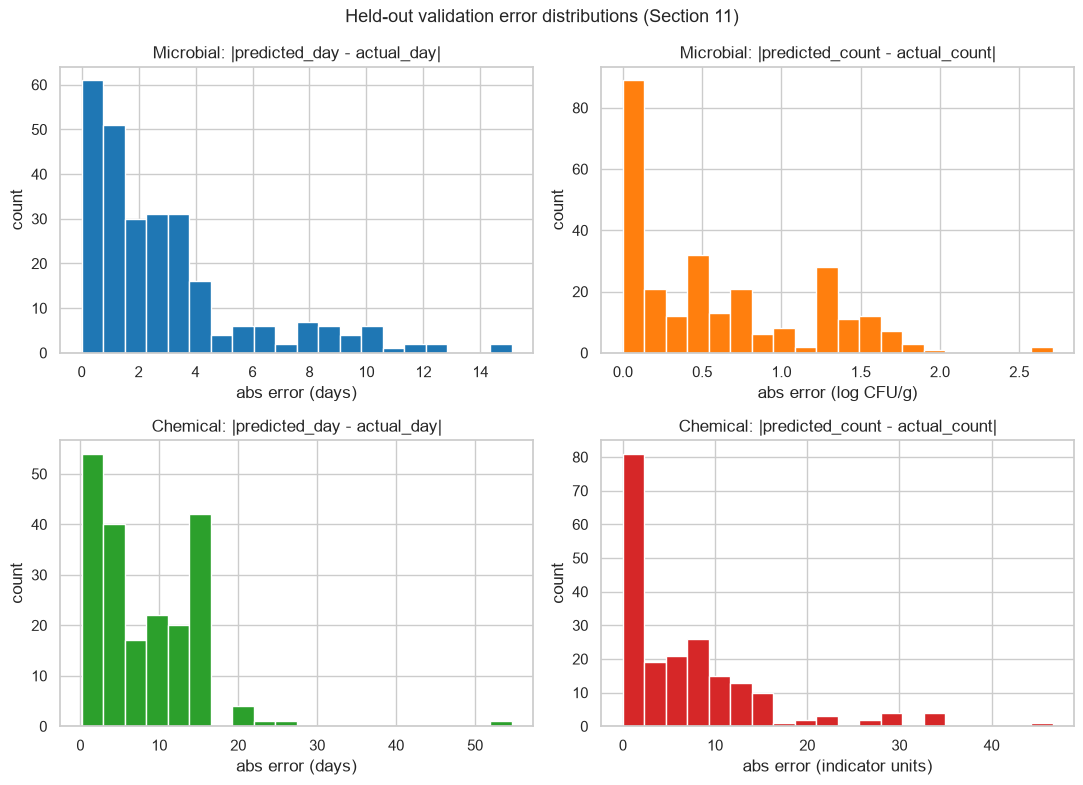

Saved C:\Users\safae\projects\ML\data\processed\figures\held_out_validation_errors.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].hist(micro_holdout["abs_err_day"].dropna(), bins=20, color="tab:blue")
axes[0, 0].set(xlabel="abs error (days)", ylabel="count", title="Microbial: |predicted_day - actual_day|")
axes[0, 1].hist(micro_holdout["abs_err_count"].dropna(), bins=20, color="tab:orange")
axes[0, 1].set(xlabel="abs error (log CFU/g)", ylabel="count", title="Microbial: |predicted_count - actual_count|")
axes[1, 0].hist(chem_holdout["abs_err_day"].dropna(), bins=20, color="tab:green")
axes[1, 0].set(xlabel="abs error (days)", ylabel="count", title="Chemical: |predicted_day - actual_day|")
axes[1, 1].hist(chem_holdout["abs_err_count"].dropna(), bins=20, color="tab:red")
axes[1, 1].set(xlabel="abs error (indicator units)", ylabel="count", title="Chemical: |predicted_count - actual_count|")
fig.suptitle("Held-out validation error distributions (Section 11)", fontsize=13)
fig.tight_layout()
out_path = FIG_DIR / "held_out_validation_errors.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## 12. Comparison & Visualization of Imputed vs Original

Original vs imputed distributions for post_threshold_day/count, rate/lag(or ceiling)
parameter distributions split by `data_completeness_status`, a gallery of overlaid
observed+reconstructed curves, and an uncertainty band from GPR's posterior std (or
RFR's per-tree spread where RFR won) propagated through the model equation via Monte
Carlo sampling.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, col, title in [
    (axes[0, 0], "post_threshold_(day)", "Microbial: post_threshold_(day)"),
    (axes[0, 1], "post_threshold_count", "Microbial: post_threshold_count"),
]:
    orig = df_micro_cls[col].dropna()
    recon_mask = micro_recon["data_completeness_status"] == "censored_reconstructed"
    recon_vals = micro_recon.loc[recon_mask, "post_day_reconstructed" if "day" in col else "post_count_reconstructed"].dropna()
    ax.hist(orig, bins=25, alpha=0.5, label="original (observed)", color="tab:blue", density=True)
    ax.hist(recon_vals, bins=25, alpha=0.5, label="reconstructed", color="tab:red", density=True)
    ax.set(xlabel=col, ylabel="density", title=title)
    ax.legend()

for ax, col, title in [
    (axes[1, 0], "post_threshold_(day)", "Chemical: post_threshold_(day)"),
    (axes[1, 1], "post_threshold_count", "Chemical: post_threshold_count"),
]:
    orig = df_chem_cls[col].dropna()
    recon_mask = chem_recon["data_completeness_status"] == "censored_reconstructed"
    recon_vals = chem_recon.loc[recon_mask, "post_day_reconstructed" if "day" in col else "post_count_reconstructed"].dropna()
    ax.hist(orig, bins=25, alpha=0.5, label="original (observed)", color="tab:green", density=True)
    ax.hist(recon_vals, bins=25, alpha=0.5, label="reconstructed", color="tab:orange", density=True)
    ax.set(xlabel=col, ylabel="density", title=title)
    ax.legend()

fig.suptitle("Original vs reconstructed distributions", fontsize=13)
fig.tight_layout()
out_path = FIG_DIR / "original_vs_reconstructed_distributions.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = {"observed": "tab:blue", "censored_reconstructed": "tab:red",
           "censored_unreconstructed": "tab:gray", "missing_y0_excluded": "tab:purple"}

for status, color in palette.items():
    sub = micro_recon[micro_recon["data_completeness_status"] == status]
    if "rate_hat" in sub.columns and sub["rate_hat"].notna().any():
        axes[0].hist(sub["rate_hat"].dropna(), bins=15, alpha=0.5, label=status, color=color)
    if "lag_hat" in sub.columns and sub["lag_hat"].notna().any():
        axes[1].hist(sub["lag_hat"].dropna(), bins=15, alpha=0.5, label=status, color=color)

observed_rows = micro_joined_diag[micro_joined_diag["censoring_type"] == "observed"]
axes[0].hist(observed_rows["primary_rate"].dropna(), bins=15, alpha=0.5, label="observed (fitted)", color="tab:blue")
axes[1].hist(observed_rows["primary_lag"].dropna(), bins=15, alpha=0.5, label="observed (fitted)", color="tab:blue")
axes[0].set(xlabel="mu_max", ylabel="count", title="Microbial: rate distribution by data_completeness_status")
axes[0].legend(fontsize=7)
axes[1].set(xlabel="lag (days)", ylabel="count", title="Microbial: lag distribution by data_completeness_status")
axes[1].legend(fontsize=7)
fig.tight_layout()
out_path = FIG_DIR / "microbial_rate_lag_by_completeness.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

In [ ]:
fig, axes = plt.subplots(1, len(palette), figsize=(4 * len(palette), 3.5), squeeze=False)
rng = np.random.default_rng(RANDOM_STATE)
recon_joined = df_micro_cls.join(micro_recon, how="left", rsuffix="_recon")

for j, (status, color) in enumerate(palette.items()):
    ax = axes[0, j]
    sub = recon_joined[recon_joined["data_completeness_status"] == status]
    if len(sub) == 0:
        ax.axis("off")
        continue
    row = sub.iloc[rng.integers(0, len(sub))]
    t_obs, y_obs, _ = extract_points(row)
    ax.scatter(t_obs, y_obs, color="black", zorder=5, label="observed pts")
    if pd.notna(row.get("post_day_reconstructed")):
        ax.scatter([row["post_day_reconstructed"]], [row["post_count_reconstructed"]],
                   color="red", marker="x", s=80, zorder=6, label="reconstructed pt")
        if pd.notna(row.get("rate_hat")) and row["censoring_type"] != "missing_y0":
            model_fn = gompertz_model if row.get("fit_model_used") == "gompertz" else baranyi_model
            y0 = row["initial_count_(day_0)"]
            t_grid = np.linspace(0, row["post_day_reconstructed"] * 1.2, 100)
            ax.plot(t_grid, model_fn(t_grid, y0, row["ymax_hat"], row["rate_hat"], row["lag_hat"]), "--", color="tab:orange")
    ax.set_title(status, fontsize=8)
    ax.set_xlabel("day")
    ax.set_ylabel("log CFU/g")

fig.suptitle("Microbial: observed + reconstructed curve gallery (one example per status)", fontsize=12)
fig.tight_layout()
out_path = FIG_DIR / "microbial_reconstruction_gallery.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

In [ ]:
def monte_carlo_uncertainty_band(pipeline, is_gpr, feat_row, y0, ymax_hat, lag_hat_or_none, model_fn,
                                  t_grid, n_draws=200, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    if is_gpr:
        mean, std = pipeline.predict(feat_row, return_std=True)
        rate_draws = rng.normal(mean[0], max(std[0], 1e-6), n_draws)
    else:
        rfr = pipeline.named_steps["rfr"]
        pre = pipeline.named_steps["pre"]
        X_enc = pre.transform(feat_row)
        tree_preds = np.array([est.predict(X_enc)[0] for est in rfr.estimators_])
        rate_draws = rng.choice(tree_preds, size=n_draws, replace=True)
    curves = np.array([model_fn(t_grid, y0, ymax_hat, r, lag_hat_or_none) for r in rate_draws])
    return np.percentile(curves, [5, 50, 95], axis=0)


_winner_rate, _rate_pipeline = fitted_pipelines[("microbial", "rate")]
_is_gpr = _winner_rate == "GPR"
_example_row = df_micro_cls[df_micro_cls["censoring_type"] == "fully_censored"].join(micro_fits, how="left").iloc[0]
_feat_row = fill_numeric(build_feature_frame(pd.DataFrame([_example_row]))[ALL_FEATURES], MICRO_NUMERIC_MEDIANS)
_y0_ex = _example_row["initial_count_(day_0)"]
_lag_hat_ex = micro_lag_pipeline.predict(_feat_row)[0]
_ymax_hat_ex = (_example_row["upper_level_threshold_(log_cfu/g)"] + MICRO_YMAX_HAT_MARGIN
                if pd.notna(_example_row["upper_level_threshold_(log_cfu/g)"]) else _y0_ex + 5)
_t_grid_ex = np.linspace(0, 40, 100)
_model_fn_ex = gompertz_model if _example_row.get("fit_model_used") == "gompertz" else baranyi_model

p5, p50, p95 = monte_carlo_uncertainty_band(_rate_pipeline, _is_gpr, _feat_row, _y0_ex, _ymax_hat_ex, _lag_hat_ex, _model_fn_ex, _t_grid_ex)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(_t_grid_ex, p50, color="tab:blue", label="median prediction")
ax.fill_between(_t_grid_ex, p5, p95, alpha=0.3, color="tab:blue", label="5th-95th percentile band")
uncertainty_label = "GPR posterior std" if _is_gpr else "RFR per-tree spread (approximate proxy)"
ax.set_title(f"Example reconstructed curve with Monte Carlo uncertainty band\n(rate uncertainty source: {uncertainty_label})", fontsize=11)
ax.set_xlabel("day")
ax.set_ylabel("log CFU/g")
ax.legend()
fig.tight_layout()
out_path = FIG_DIR / "example_uncertainty_band.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")